# 🤖 Klasik Makine Öğrenmesi — Adım Adım Tam Pipeline
## QML Workshop · Temel Referans Defteri
---
| | |
|---|---|
| **Seviye** | Başlangıç → Orta |
| **Süre** | ~2–3 saat |
| **Veri Seti** | Titanic (Kaggle) + Sentetik |
| **Kütüphaneler** | NumPy, Pandas, Scikit-learn, Matplotlib, Seaborn |
---
## 📋 İçerik Akışı
| # | Bölüm | Amaç |
|---|-------|------|
| 0 | Kurulum & İçe Aktarma | Ortamı hazırla |
| 1 | Makine Öğrenmesi Nedir? | Kavramsal temel |
| 2 | Veri Yükleme & İlk Bakış | Veriyle tanış |
| 3 | Keşifsel Veri Analizi (EDA) | Hikâyeyi anla |
| 4 | Veri Ön İşleme | Modele hazırla |
| 5 | Özellik Mühendisliği | Bilgiyi çıkar |
| 6 | Model Seçimi & Eğitim | Öğren |
| 7 | Değerlendirme | Ne kadar iyi? |
| 8 | Hiperparametre Optimizasyonu | En iyiyi bul |
| 9 | Tam Sklearn Pipeline | Hepsini bir araya getir |
| 10 | QML'ye Köprü | Sıradaki adım |
> **💡 Her bölümde:** _"Ne yapıyoruz?" · "Neden yapıyoruz?" · "Kod" · "Görsel"_

---
# BÖLÜM 0: Kurulum & İçe Aktarma
> Araç çantamızı hazırlıyoruz. Her kütüphane belirli bir görevi üstlenir.

In [1]:
# ─── Kurulum (Colab'da gerekirse) ───────────────────────────────
# !pip install seaborn scikit-learn pandas numpy matplotlib --quiet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, to_rgba
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn — veri işleme
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     GridSearchCV, learning_curve,
                                     StratifiedKFold)
from sklearn.preprocessing  import (StandardScaler, MinMaxScaler,
                                     LabelEncoder, OneHotEncoder)
from sklearn.impute          import SimpleImputer
from sklearn.pipeline        import Pipeline
from sklearn.compose         import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

# Sklearn — modeller
from sklearn.linear_model   import LogisticRegression
from sklearn.tree           import DecisionTreeClassifier, export_text
from sklearn.ensemble       import (RandomForestClassifier,
                                    GradientBoostingClassifier)
from sklearn.svm            import SVC
from sklearn.neighbors      import KNeighborsClassifier
from sklearn.naive_bayes    import GaussianNB

# Sklearn — metrikler
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_curve, auc,
                              precision_recall_curve, f1_score)

# ─── Görsel ayarlar ──────────────────────────────────────────────
plt.rcParams.update({
    'font.family':      'DejaVu Sans',
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.25,
    'grid.color':       '#90A4AE',
})
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

# ─── Renk paleti ─────────────────────────────────────────────────
PAL = dict(
    navy='#1A237E', blue='#1565C0', red='#C62828', green='#2E7D32',
    orange='#E65100', purple='#7C4DFF', teal='#00695C', gray='#546E7A',
    ltgray='#ECEFF1', gold='#F9A825',
)
np.random.seed(42)
print('✅ Tüm kütüphaneler yüklendi!')
print(f'   NumPy     : {np.__version__}')
print(f'   Pandas    : {pd.__version__}')
import sklearn; print(f'   Scikit-learn: {sklearn.__version__}')

✅ Tüm kütüphaneler yüklendi!
   NumPy     : 2.0.2
   Pandas    : 2.2.2
   Scikit-learn: 1.6.1


---
# BÖLÜM 1: Makine Öğrenmesi Nedir?
## 🤔 Klasik Programlama vs Makine Öğrenmesi
```
Klasik Programlama:
    Veri + Kurallar  →  [Program]  →  Cevap
Makine Öğrenmesi:
    Veri + Cevaplar  →  [Eğitim]  →  Kurallar (Model)
```
## 📊 Üç Temel Paradigma
| Paradigma | Ne yapar? | Örnek |
|-----------|-----------|-------|
| **Gözetimli (Supervised)** | Etiketli veriyle öğrenir | Spam tespiti, hastalık tahmini |
| **Gözetimsiz (Unsupervised)** | Kendi örüntülerini bulur | Müşteri segmentasyonu, anomali |
| **Pekiştirmeli (Reinforcement)** | Ödül/ceza ile öğrenir | Oyun oynama, robot kontrolü |
> **Bu notebook:** Gözetimli öğrenme · İkili sınıflandırma · Titanic hayatta kalma tahmini

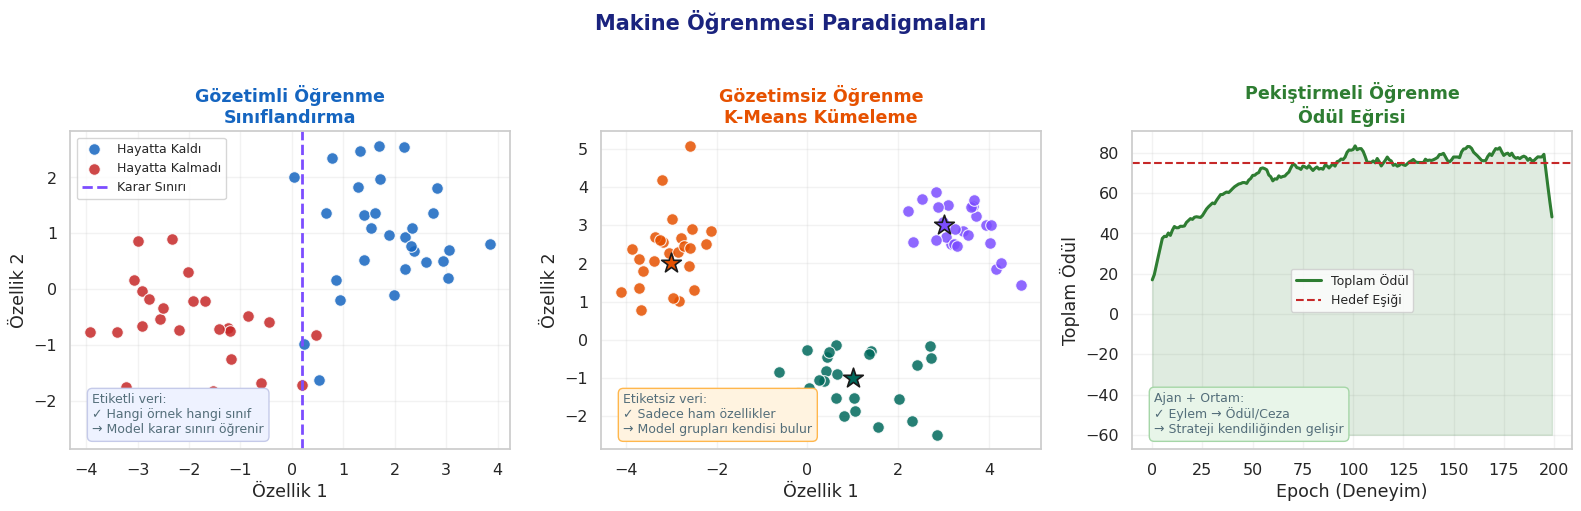

In [2]:
# ─────────────────────────────────────────────────────────────────
# DEMO 1.1: ML Paradigmalarının Görsel Karşılaştırması
# Neden? → Hangi probleme hangi yaklaşım uygulanır, görmek için
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Makine Öğrenmesi Paradigmaları', fontsize=15,
             fontweight='700', color=PAL['navy'], y=1.02)
np.random.seed(42)

# ── Gözetimli: Sınıflandırma ───────────────────────────────────
ax = axes[0]
for cls, clr, lbl in [(0, PAL['blue'], 'Hayatta Kaldı'),
                       (1, PAL['red'],  'Hayatta Kalmadı')]:
    idx = np.random.rand(30) > 0.5
    x = np.random.randn(30) + (2 if cls == 0 else -2)
    y = np.random.randn(30) + (1 if cls == 0 else -1)
    ax.scatter(x, y, c=clr, label=lbl, s=70, edgecolors='white',
               linewidths=0.8, alpha=0.85)
ax.axvline(0.2, color=PAL['purple'], lw=2, ls='--', label='Karar Sınırı')
ax.set_title('Gözetimli Öğrenme\nSınıflandırma', fontweight='600',
             color=PAL['blue'])
ax.set_xlabel('Özellik 1'); ax.set_ylabel('Özellik 2')
ax.legend(fontsize=9)
ax.text(0.05, 0.05,
        'Etiketli veri:\n✓ Hangi örnek hangi sınıf\n→ Model karar sınırı öğrenir',
        transform=ax.transAxes, fontsize=9, color=PAL['gray'],
        bbox=dict(boxstyle='round,pad=0.4', fc='#EEF2FF', ec='#C5CAE9'))

# ── Gözetimsiz: Kümeleme ────────────────────────────────────────
ax = axes[1]
centers = [(-3, 2), (1, -1), (3, 3)]
colors  = [PAL['orange'], PAL['teal'], PAL['purple']]
for (cx, cy), clr in zip(centers, colors):
    pts = np.random.randn(25, 2) * 0.8 + [cx, cy]
    ax.scatter(pts[:,0], pts[:,1], c=clr, s=70, edgecolors='white',
               linewidths=0.8, alpha=0.85)
    ax.scatter(cx, cy, c=clr, s=220, marker='*', edgecolors='k',
               linewidths=1.2, zorder=5)
ax.set_title('Gözetimsiz Öğrenme\nK-Means Kümeleme', fontweight='600',
             color=PAL['orange'])
ax.set_xlabel('Özellik 1'); ax.set_ylabel('Özellik 2')
ax.text(0.05, 0.05,
        'Etiketsiz veri:\n✓ Sadece ham özellikler\n→ Model grupları kendisi bulur',
        transform=ax.transAxes, fontsize=9, color=PAL['gray'],
        bbox=dict(boxstyle='round,pad=0.4', fc='#FFF3E0', ec='#FFB74D'))

# ── Pekiştirmeli: Ödül Eğrisi ──────────────────────────────────
ax = axes[2]
eps = np.arange(200)
reward = -50 * np.exp(-eps/40) + 80 + np.random.randn(200) * 8
reward = np.convolve(reward, np.ones(10)/10, mode='same')
ax.plot(eps, reward, color=PAL['green'], lw=2.2, label='Toplam Ödül')
ax.fill_between(eps, reward, -60, alpha=0.15, color=PAL['green'])
ax.axhline(75, color=PAL['red'], lw=1.5, ls='--', label='Hedef Eşiği')
ax.set_title('Pekiştirmeli Öğrenme\nÖdül Eğrisi', fontweight='600',
             color=PAL['green'])
ax.set_xlabel('Epoch (Deneyim)'); ax.set_ylabel('Toplam Ödül')
ax.legend(fontsize=9)
ax.text(0.05, 0.05,
        'Ajan + Ortam:\n✓ Eylem → Ödül/Ceza\n→ Strateji kendiliğinden gelişir',
        transform=ax.transAxes, fontsize=9, color=PAL['gray'],
        bbox=dict(boxstyle='round,pad=0.4', fc='#E8F5E9', ec='#A5D6A7'))
plt.tight_layout()
plt.show()

Bu görsel, makine öğrenmesinin üç temel paradigmasını (yaklaşımlarını) yan yana karşılaştırarak özetliyor:

* **Gözetimli Öğrenme (Sınıflandırma - Sol Grafik):** Modelin etiketli (hangi gruba ait olduğu bilinen) verilerle eğitilmesini temsil eder. Grafikte mavi ("Hayatta Kaldı") ve kırmızı ("Hayatta Kalmadı") noktalarla belirtilen iki farklı sınıf var. Model, bu iki grubu birbirinden en iyi şekilde ayıran bir çizgi (mor kesikli çizgi ile gösterilen Karar Sınırı) çizmeyi öğreniyor.
* **Gözetimsiz Öğrenme (Kümeleme - Orta Grafik):** Modele verilerin etiketleri verilmez. Model (burada K-Means kullanılmış), ham verileri inceler ve aralarındaki benzerlikleri bulup onları kendi kendine gruplara ayırır. Grafikte verilerin turuncu, mor ve yeşil olmak üzere üç kümeye ayrıldığı ve her kümenin bir merkez noktasının (yıldızlar) belirlendiği görülüyor.
* **Pekiştirmeli Öğrenme (Ödül Eğrisi - Sağ Grafik):** Deneme-yanılma ve ödül/ceza mekanizmasına dayalı öğrenmeyi gösterir. Grafikteki yeşil çizgi (Toplam Ödül), ajanın deneyim (Epoch) kazandıkça doğru eylemleri yapmayı öğrendiğini ve performansının artarak kırmızı ile belirtilen "Hedef Eşiği"ne ulaştığını ifade ediyor.

Kısacası bu görsel; yapay zekanın veriden doğrudan sonuç çıkarmayı, verinin gizli yapısını keşfetmeyi veya bir ortamda en iyi stratejiyi geliştirmeyi nasıl öğrendiğini özetleyen çok başarılı bir kavramsal tablodur.

---
# BÖLÜM 2: Veri Yükleme & İlk Bakış
## ❓ Ne yapıyoruz?
Titanic yolcu verilerini yükleyip ilk bakışımızı yapıyoruz.
## ❓ Neden yapıyoruz?
Veriyi anlamadan model kurmak imkânsızdır. İlk bakış bize şunları söyler:
- Kaç satır/sütun var?
- Hangi değişkenler eksik?
- Sayısal mı, kategorik mi?
- Hedef değişken dengeli mi?
## 🎯 Hedef: `Survived` sütununu tahmin et (0=Hayır, 1=Evet)

In [3]:
# ─────────────────────────────────────────────────────────────────
# DEMO 2.1: Veri Yükleme
# Neden? → Makine öğrenmesinde her şey veriden başlar
# ─────────────────────────────────────────────────────────────────
# Titanic verisini doğrudan URL'den çek
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
try:
    df = pd.read_csv(url)
    print('✅ Titanic verisi URL\'den yüklendi')
except:
    # Offline yedek: sentetik Titanic benzeri veri
    np.random.seed(42)
    n = 891
    df = pd.DataFrame({
        'PassengerId': range(1, n+1),
        'Survived':  np.random.choice([0,1], n, p=[0.62, 0.38]),
        'Pclass':    np.random.choice([1,2,3], n, p=[0.24, 0.21, 0.55]),
        'Name':      [f'Passenger_{i}' for i in range(n)],
        'Sex':       np.random.choice(['male','female'], n, p=[0.65, 0.35]),
        'Age':       np.random.normal(29.7, 14.5, n).clip(1, 80),
        'SibSp':     np.random.choice([0,1,2,3,4], n, p=[0.68,0.23,0.06,0.02,0.01]),
        'Parch':     np.random.choice([0,1,2,3], n, p=[0.76,0.13,0.09,0.02]),
        'Fare':      np.random.exponential(32, n).clip(5, 512),
        'Cabin':     [None if np.random.rand()<0.77 else f'C{i}' for i in range(n)],
        'Embarked':  np.random.choice(['S','C','Q'], n, p=[0.72, 0.19, 0.09]),
    })
    df.loc[np.random.choice(df.index, 177, replace=False), 'Age'] = np.nan
    print('✅ Sentetik Titanic verisi oluşturuldu (offline mod)')

print(f'\n📊 Veri Boyutu: {df.shape[0]:,} satır × {df.shape[1]} sütun')
print('\n📋 İlk 5 Satır:')
df.head()

✅ Titanic verisi URL'den yüklendi

📊 Veri Boyutu: 891 satır × 12 sütun

📋 İlk 5 Satır:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# ─────────────────────────────────────────────────────────────────
# DEMO 2.2: Veri Özeti — dtypes, eksik değerler, istatistikler
# Neden? → Her sütunun doğasını (sayısal/kategorik/eksik) anlamak için
# ─────────────────────────────────────────────────────────────────
print('═'*60)
print('  VERİ ÖZET TABLOSU')
print('═'*60)
summary = pd.DataFrame({
    'Tip':       df.dtypes,
    'Eksik #':   df.isnull().sum(),
    'Eksik %':   (df.isnull().sum() / len(df) * 100).round(1),
    'Benzersiz': df.nunique(),
    'Örnek':     [str(df[c].dropna().iloc[0])[:20] for c in df.columns],
})
summary = summary.sort_values('Eksik %', ascending=False)
print(summary.to_string())

print(f'\n🎯 Hedef Dağılımı:')
vc = df['Survived'].value_counts()
print(f'   Hayatta Kalmadı (0): {vc.get(0,0):4d}  ({vc.get(0,0)/len(df)*100:.1f}%)')
print(f'   Hayatta Kaldı   (1): {vc.get(1,0):4d}  ({vc.get(1,0)/len(df)*100:.1f}%)')

════════════════════════════════════════════════════════════
  VERİ ÖZET TABLOSU
════════════════════════════════════════════════════════════
                 Tip  Eksik #  Eksik %  Benzersiz                 Örnek
Cabin         object      687     77.1        147                   C85
Age          float64      177     19.9         88                  22.0
Embarked      object        2      0.2          3                     S
PassengerId    int64        0      0.0        891                     1
Name          object        0      0.0        891  Braund, Mr. Owen Har
Pclass         int64        0      0.0          3                     3
Survived       int64        0      0.0          2                     0
Sex           object        0      0.0          2                  male
Parch          int64        0      0.0          7                     0
SibSp          int64        0      0.0          7                     1
Fare         float64        0      0.0        248                 

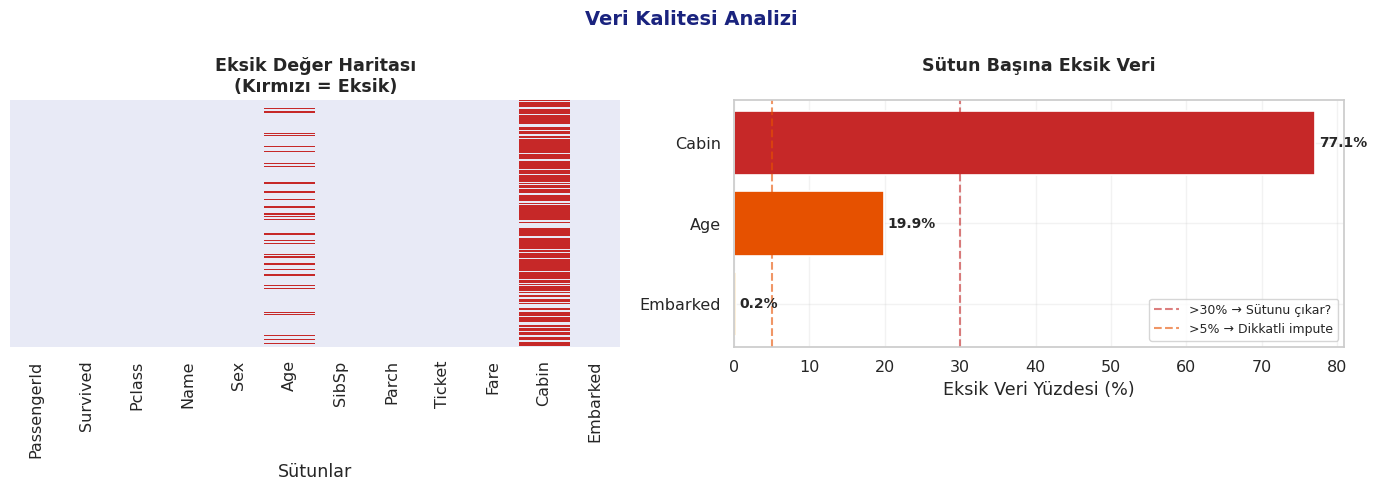

📌 Sonuç: Age ~%20 eksik → Medyan ile doldur | Cabin ~%77 eksik → Sütunu çıkar


In [5]:
# ─────────────────────────────────────────────────────────────────
# DEMO 2.3: Eksik Değer Haritası
# Neden? → Hangi sütunlar ne kadar eksik? Görsel olarak görmek
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Veri Kalitesi Analizi', fontsize=14, fontweight='700',
             color=PAL['navy'])

# Isı haritası
ax = axes[0]
missing_mask = df.isnull()
sns.heatmap(missing_mask, cbar=False, cmap=['#E8EAF6','#C62828'],
            yticklabels=False, ax=ax)
ax.set_title('Eksik Değer Haritası\n(Kırmızı = Eksik)', fontweight='600')
ax.set_xlabel('Sütunlar')

# Eksik yüzde bar
ax = axes[1]
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=True)
missing_pct = missing_pct[missing_pct > 0]
colors_bar = [PAL['red'] if v > 30 else PAL['orange'] if v > 5 else PAL['gold']
              for v in missing_pct]
bars = ax.barh(missing_pct.index, missing_pct.values,
               color=colors_bar, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, missing_pct.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='600')
ax.set_xlabel('Eksik Veri Yüzdesi (%)')
ax.set_title('Sütun Başına Eksik Veri\n', fontweight='600')
ax.axvline(30, color=PAL['red'], lw=1.5, ls='--', alpha=0.6, label='>30% → Sütunu çıkar?')
ax.axvline(5,  color=PAL['orange'], lw=1.5, ls='--', alpha=0.6, label='>5% → Dikkatli impute')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print('📌 Sonuç: Age ~%20 eksik → Medyan ile doldur | Cabin ~%77 eksik → Sütunu çıkar')

Bu görsel, bir veri setindeki (sütun isimlerinden Titanic veri seti olduğu anlaşılıyor) **eksik değerleri (missing values)** analiz eden iki aşamalı bir tablodur.

Temel olarak şu bilgileri sunar:

* **Sol Grafik (Eksik Değer Haritası):** Veri setindeki her bir satır ve sütuna kuşbakışı bakar. Kırmızı renkle boyanmış kısımlar, o hücrede verinin olmadığını gösterir. Bu haritaya bakarak "Cabin" (Kabin) ve "Age" (Yaş) sütunlarında belirgin boşluklar olduğunu anında görebiliyoruz.
* **Sağ Grafik (Sütun Başına Eksik Veri Yüzdesi):** Eksik verilerin tam oranını yatay çubuk grafiklerle gösterir.
    * **Cabin** sütununun **%77.1'i** eksiktir.
    * **Age** sütununun **%19.9'u** eksiktir.
    * **Embarked** sütununun ise sadece **%0.2'si** eksiktir.

**Grafiğin Verdiği Tavsiye:** Sağ grafikteki dikey kesik çizgiler, veri ön işleme adımları için bir rehber niteliğindedir. %30 sınırını aşan "Cabin" sütununun modelden tamamen çıkarılması gerektiğine (>30% Sütunu çıkar?), %5 sınırını aşan "Age" sütununun ise dikkatli bir şekilde istatistiksel yöntemlerle (örneğin ortalama veya medyan değeri ile) doldurulması gerektiğine (>5% Dikkatli impute) işaret etmektedir.

---
# BÖLÜM 3: Keşifsel Veri Analizi (EDA - Exploratory Data Analysis)
## ❓ Ne yapıyoruz?
Değişkenlerin dağılımını, birbirleriyle ilişkisini ve hedef değişkenle bağlantısını görselleştiriyoruz.
## ❓ Neden yapıyoruz?
- Hangi özellikler tahmin için güçlü? → **Feature importance ipuçları**
- Dağılım ne şekilde? → **Hangi modeller uygun?**
- Aykırı değerler var mı? → **Temizlik gerekli mi?**

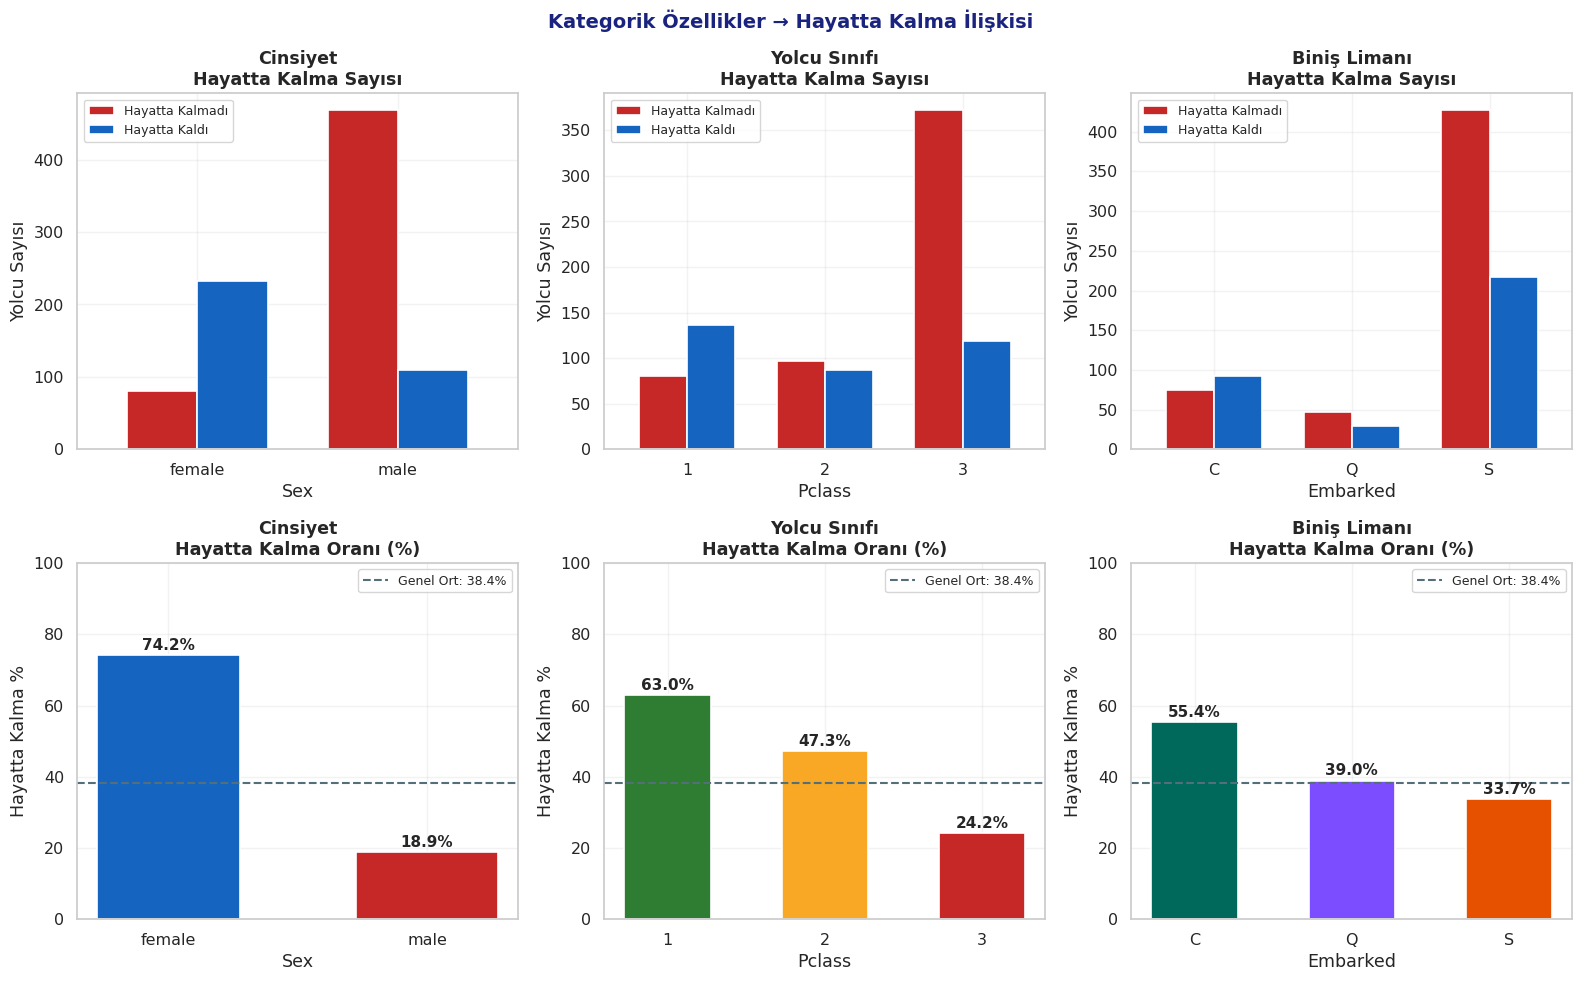

📌 Kadınlar, 1. sınıf ve Cherbourg'dan binenler daha fazla hayatta kaldı!


In [6]:
# ─────────────────────────────────────────────────────────────────
# DEMO 3.1: Hedef Değişkene Göre Kategorik Özellikler
# Neden? → Kategorik değişkenlerin hayatta kalmayla ilişkisi
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Kategorik Özellikler → Hayatta Kalma İlişkisi',
             fontsize=14, fontweight='700', color=PAL['navy'])
cats = [
    ('Sex',      'Cinsiyet',       [PAL['blue'], PAL['red']]),
    ('Pclass',   'Yolcu Sınıfı',   [PAL['green'], PAL['gold'], PAL['red']]),
    ('Embarked', 'Biniş Limanı',   [PAL['teal'], PAL['purple'], PAL['orange']]),
]
for i, (col, title, clrs) in enumerate(cats):
    # Sayım grafiği
    ax = axes[0, i]
    ct = pd.crosstab(df[col], df['Survived'])
    ct.plot(kind='bar', ax=ax, color=[PAL['red'], PAL['blue']],
            edgecolor='white', linewidth=1.2, width=0.7)
    ax.set_title(f'{title}\nHayatta Kalma Sayısı', fontweight='600')
    ax.set_xlabel(col); ax.set_ylabel('Yolcu Sayısı')
    ax.legend(['Hayatta Kalmadı','Hayatta Kaldı'], fontsize=9)
    ax.tick_params(axis='x', rotation=0)
    # Oran grafiği
    ax = axes[1, i]
    surv_rate = df.groupby(col)['Survived'].mean() * 100
    bars = ax.bar(surv_rate.index.astype(str), surv_rate.values,
                  color=clrs[:len(surv_rate)], edgecolor='white',
                  linewidth=1.2, width=0.55)
    for bar, val in zip(bars, surv_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1.5, f'{val:.1f}%',
                ha='center', fontsize=11, fontweight='700')
    ax.axhline(df['Survived'].mean()*100, color=PAL['gray'],
               lw=1.5, ls='--', label=f'Genel Ort: {df["Survived"].mean()*100:.1f}%')
    ax.set_ylim(0, 100)
    ax.set_title(f'{title}\nHayatta Kalma Oranı (%)', fontweight='600')
    ax.set_xlabel(col); ax.set_ylabel('Hayatta Kalma %')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print('📌 Kadınlar, 1. sınıf ve Cherbourg\'dan binenler daha fazla hayatta kaldı!')

Bu görsel, ünlü **Titanic veri setindeki** yolcuların hayatta kalma durumlarını üç farklı kategorik özelliğe (Cinsiyet, Yolcu Sınıfı ve Biniş Limanı) göre analiz etmektedir.

Tablo iki bölümden oluşuyor: Üst satır yolcuların toplam sayılarını, alt satır ise yüzdelik hayatta kalma oranlarını (genel ortalama olan %38.4 baz alınarak) gösteriyor. Görselden çıkarılabilecek temel sonuçlar şunlardır:

* **Cinsiyet (Sex):** Hayatta kalma ihtimalini en çok etkileyen faktördür. Kadınların hayatta kalma oranı **%74.2** iken, erkeklerde bu oran sadece **%18.9**'dur. Sayısal olarak da en çok can kaybı erkekler arasında yaşanmıştır.
* **Yolcu Sınıfı (Pclass):** Sosyoekonomik durumun kurtarılma önceliğinde net bir etkisi olduğu görülüyor. 1. sınıf yolcuların hayatta kalma oranı en yüksek seviyedeyken (**%63.0**), bilet sınıfı düştükçe bu oran azalmış ve 3. sınıf yolcuların çok büyük bir kısmı hayatını kaybetmiştir (hayatta kalma oranı **%24.2**).
* **Biniş Limanı (Embarked):** 'C' (Cherbourg) limanından binenlerin hayatta kalma oranı (**%55.4**) diğer limanlara göre belirgin şekilde daha yüksektir. Gemiye en çok yolcunun bindiği 'S' (Southampton) limanı ise %33.7 ile en düşük orana sahiptir.

**Özetle:** Bu grafikler, tahliye sırasında "önce kadınlar ve çocuklar" kuralının işlediğini ve üst sınıf yolcuların filikalara erişimde daha avantajlı olduğunu istatistiksel olarak net bir şekilde kanıtlamaktadır.

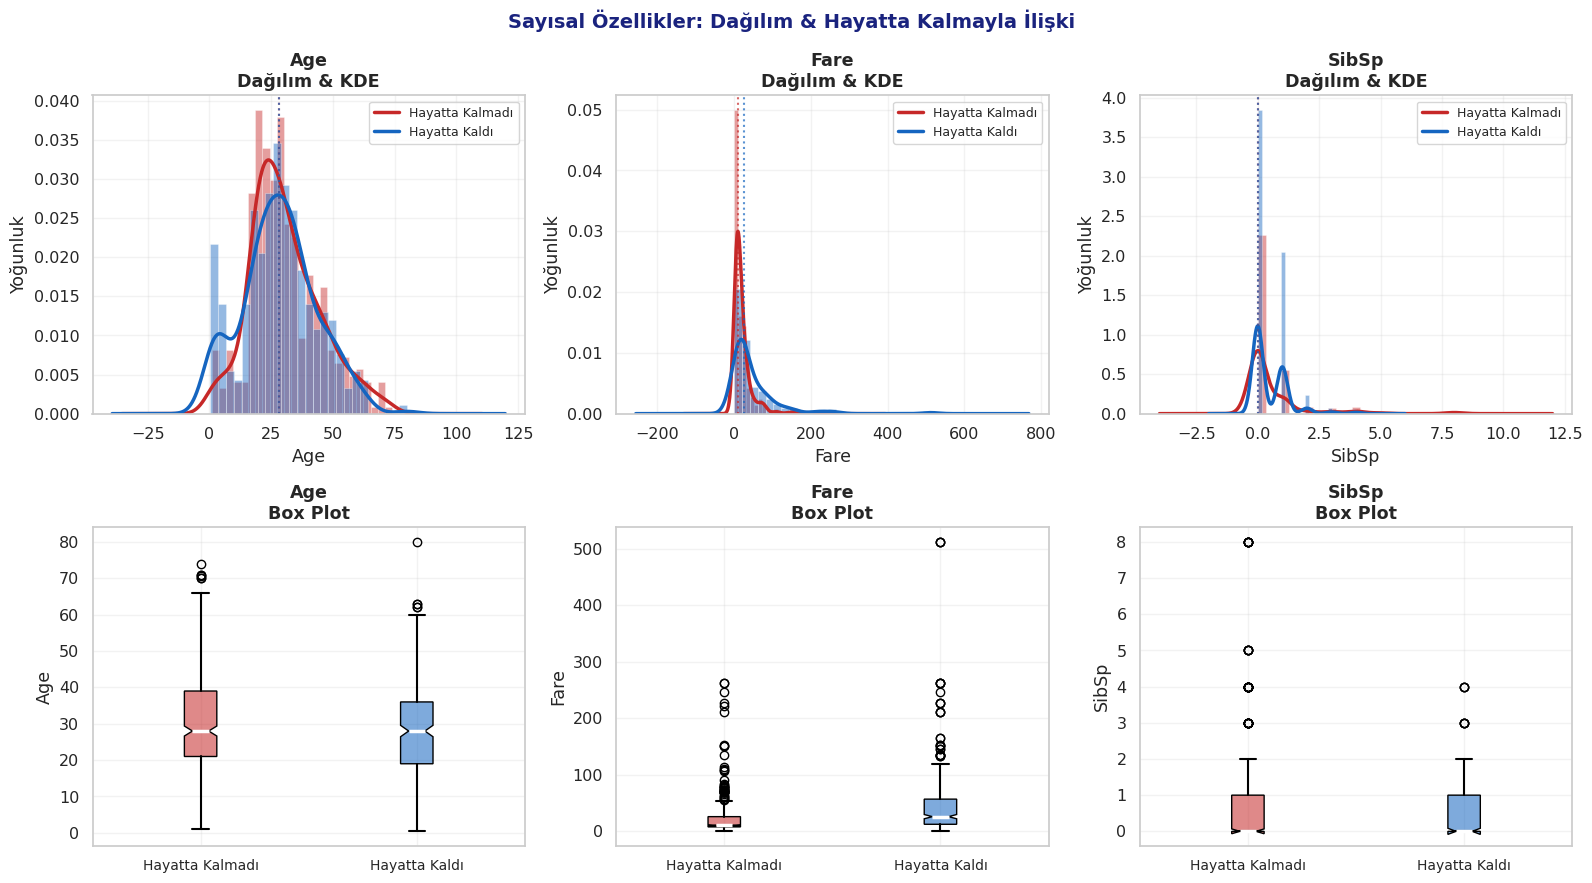

In [7]:
# ─────────────────────────────────────────────────────────────────
# DEMO 3.2: Sayısal Özellikler — Dağılım & KDE
# Neden? → Sayısal değişkenlerin dağılımı ve aykırı değerleri görmek
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Sayısal Özellikler: Dağılım & Hayatta Kalmayla İlişki',
             fontsize=14, fontweight='700', color=PAL['navy'])
num_cols = ['Age', 'Fare', 'SibSp']
for i, col in enumerate(num_cols):
    data_clean = df[col].dropna()
    # KDE plot (üst satır)
    ax = axes[0, i]
    for surv, clr, lbl in [(0, PAL['red'], 'Hayatta Kalmadı'),
                            (1, PAL['blue'], 'Hayatta Kaldı')]:
        subset = df[df['Survived']==surv][col].dropna()
        ax.hist(subset, bins=25, alpha=0.45, color=clr, density=True,
                edgecolor='white', linewidth=0.5)
        subset.plot.kde(ax=ax, color=clr, lw=2.5, label=lbl)
    ax.set_title(f'{col}\nDağılım & KDE', fontweight='600')
    ax.set_xlabel(col); ax.set_ylabel('Yoğunluk')
    ax.legend(fontsize=9)
    # Medyan çizgileri
    for surv, clr in [(0, PAL['red']), (1, PAL['blue'])]:
        med = df[df['Survived']==surv][col].median()
        ax.axvline(med, color=clr, lw=1.5, ls=':', alpha=0.7)
    # Box plot (alt satır)
    ax = axes[1, i]
    groups = [df[df['Survived']==s][col].dropna() for s in [0, 1]]
    bp = ax.boxplot(groups, patch_artist=True, notch=True,
                    medianprops=dict(color='white', lw=2.5),
                    whiskerprops=dict(lw=1.5),
                    capprops=dict(lw=1.5))
    for patch, clr in zip(bp['boxes'], [PAL['red'], PAL['blue']]):
        patch.set_facecolor(to_rgba(clr, 0.55))
    ax.set_xticklabels(['Hayatta Kalmadı', 'Hayatta Kaldı'], fontsize=10)
    ax.set_title(f'{col}\nBox Plot', fontweight='600')
    ax.set_ylabel(col)
plt.tight_layout()
plt.show()

Bu görsel, Titanic veri setindeki üç **sayısal özelliğin** (Yaş, Bilet Ücreti ve Kardeş/Eş Sayısı) yolcuların hayatta kalma durumlarıyla olan ilişkisini iki farklı istatistiksel grafikle (üstte Dağılım/KDE, altta Kutu Grafiği - Box Plot) detaylı olarak inceliyor.

Grafiklerden çıkarılabilecek temel bulgular şunlardır:

* **Yaş (Age):** Genel olarak hayatta kalanlar (mavi) ve hayatını kaybedenlerin (kırmızı) yaş dağılımları ve medyanları (kutu içindeki beyaz çizgiler) birbirine yakındır. Ancak üstteki grafikte 0-5 yaş aralığında mavi çizginin oluşturduğu belirgin tepe noktası, **küçük çocukların kurtarılmada önceliğe sahip olduğunu** net bir şekilde gösteriyor.
* **Bilet Ücreti (Fare):** Hayatta kalma durumuyla en güçlü ilişkisi olan sayısal değişken budur. Hem üstteki dağılımın sağa doğru uzaması hem de alttaki mavi kutunun kırmızının çok daha üstünde yer alması, **daha yüksek ücret ödeyenlerin (1. sınıf yolcuların) hayatta kalma şansının çok daha yüksek olduğunu** kanıtlıyor.
* **Kardeş/Eş Sayısı (SibSp):** Yolcuların çok büyük bir kısmı tek başına veya sadece 1 yakınıyla seyahat etmiştir (0 ve 1 civarındaki yığılma). Alttaki kutu grafiğinde yer alan aykırı değerlere (yuvarlak noktalar) bakıldığında, **çok kalabalık ailelerin (4 ve üzeri kişi) çoğunlukla hayatta kalamadığı** görülmektedir.

**Özetle:** Bu görsel analiz, önceki grafikleri destekleyerek bilet ücreti (sosyoekonomik durum) ve küçük yaşın hayatta kalma ihtimalini istatistiksel olarak artıran önemli faktörler olduğunu doğrulamaktadır.

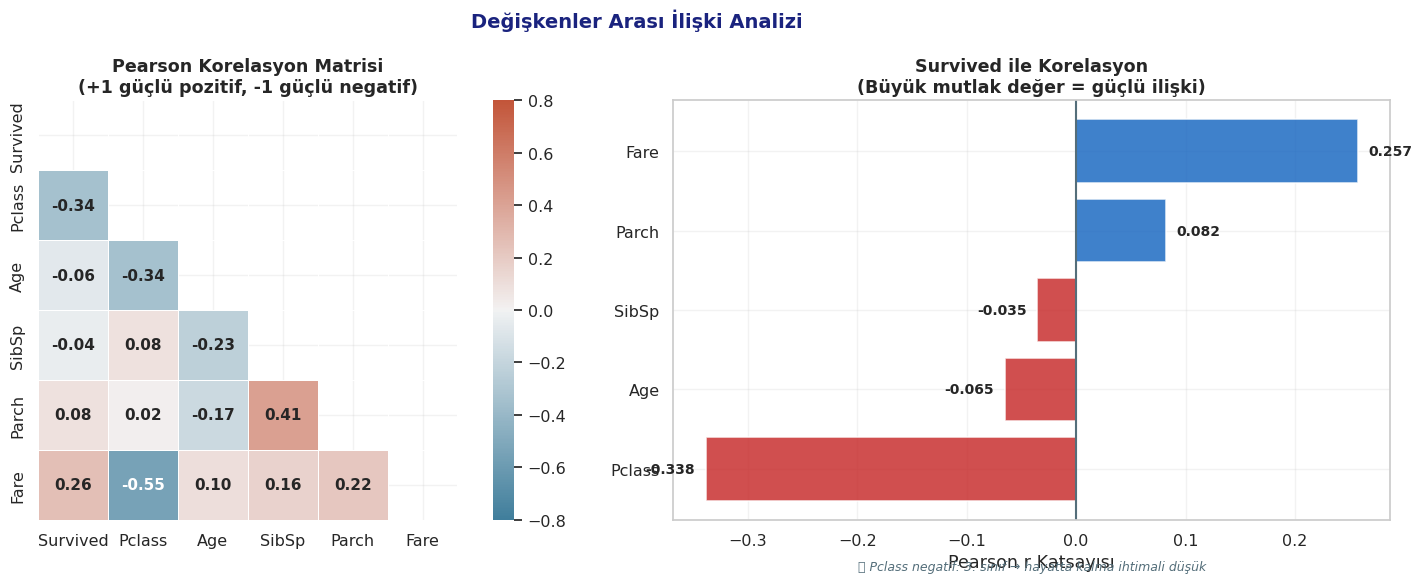

In [8]:
# ─────────────────────────────────────────────────────────────────
# DEMO 3.3: Korelasyon Isı Haritası + Pair Plot
# Neden? → Değişkenler arası ilişkiyi öğrenmek için
#          Çok korelasyonlu değişkenler modeli bozabilir!
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Değişkenler Arası İlişki Analizi', fontsize=14,
             fontweight='700', color=PAL['navy'])
# Sayısal sütunlar
num_df = df[['Survived','Pclass','Age','SibSp','Parch','Fare']].copy()
num_df['Age'] = num_df['Age'].fillna(num_df['Age'].median())

# Korelasyon ısı haritası
ax = axes[0]
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=0.8, vmin=-0.8,
            center=0, annot=True, fmt='.2f', linewidths=0.5,
            linecolor='white', ax=ax, square=True,
            annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('Pearson Korelasyon Matrisi\n(+1 güçlü pozitif, -1 güçlü negatif)',
             fontweight='600')

# Survived korelasyon bar
ax = axes[1]
surv_corr = corr['Survived'].drop('Survived').sort_values()
colors_c = [PAL['red'] if v < 0 else PAL['blue'] for v in surv_corr]
bars = ax.barh(surv_corr.index, surv_corr.values, color=colors_c,
               alpha=0.82, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, surv_corr.values):
    ax.text(val + (0.01 if val >= 0 else -0.01),
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=10, fontweight='600')
ax.axvline(0, color=PAL['gray'], lw=1.5)
ax.set_title("Survived ile Korelasyon\n(Büyük mutlak değer = güçlü ilişki)",
             fontweight='600')
ax.set_xlabel('Pearson r Katsayısı')
ax.text(0.5, -0.12, '💡 Pclass negatif: 3. sınıf → hayatta kalma ihtimali düşük',
        transform=ax.transAxes, ha='center', fontsize=9,
        color=PAL['gray'], style='italic')
plt.tight_layout()
plt.show()

Bu görsel, veri setindeki sayısal değişkenlerin birbirleriyle ve özellikle hedef değişken olan "Hayatta Kalma" (Survived) durumuyla olan **doğrusal ilişkilerini (korelasyonlarını)** özetlemektedir.

Grafik iki temel bölümden oluşuyor:

* **Sol Taraf (Korelasyon Matrisi):** Tüm sayısal değişkenlerin birbirleriyle olan ilişkisini gösterir. Değerler +1'e yaklaştıkça aynı yönde (biri artarken diğeri artar), -1'e yaklaştıkça ters yönde (biri artarken diğeri azalır) güçlü bir ilişki olduğunu anlarız. Örneğin, **Pclass ve Fare** arasındaki **-0.55**'lik değer mantıklı bir ters orantıyı gösterir: Sınıf numarası küçüldükçe (1. sınıfa geçildikçe) bilet ücreti artmaktadır.
* **Sağ Taraf (Survived ile Korelasyon):** Sadece "Hayatta Kalma" durumunu etkileyen faktörleri matematiksel önem sırasına göre listeler. Çubuk boyu ne kadar uzunsa, ilişki o kadar güçlüdür.
    * **Pclass (-0.338):** Hayatta kalmayı en çok etkileyen faktördür. Negatif olması, sınıf numarası büyüdükçe (3. sınıf yolcusu oldukça) hayatta kalma ihtimalinin net bir şekilde düştüğünü gösterir.
    * **Fare (0.257):** En güçlü pozitif etkendir. Bilet için daha fazla ücret ödeyenlerin hayatta kalma ihtimali daha yüksektir.
    * Yaş (Age) ve beraberindeki aile üyesi sayısı (SibSp, Parch) gibi diğer özelliklerin genel toplama bakıldığında *doğrusal* olarak hayatta kalma üzerinde çok zayıf bir etkisi olduğu görülmektedir.

**Özetle:** Bu analiz bize makine öğrenmesi modeli kurarken **Yolcu Sınıfı (Pclass)** ve **Bilet Ücreti (Fare)** değişkenlerinin, kimin hayatta kalıp kalmayacağını tahmin etmede elimizdeki en güçlü sayısal veriler olduğunu gösteriyor.

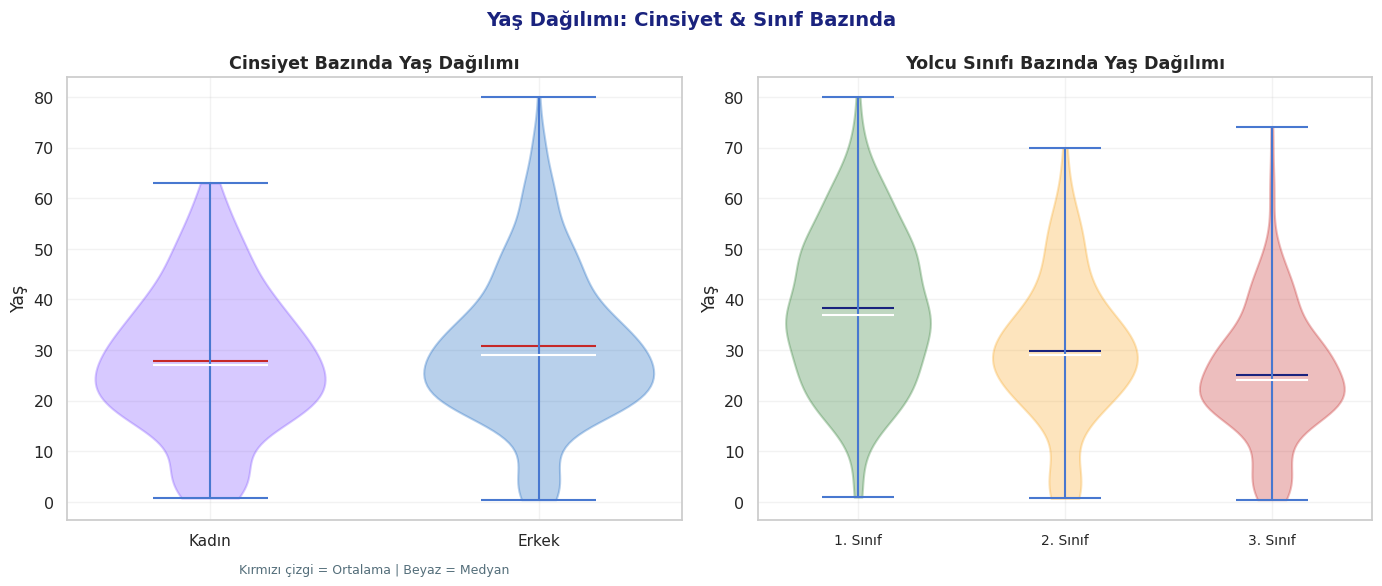

📌 1. sınıf yolcular daha yaşlı → sosyoekonomik durum yaşla ilişkili


In [9]:
# ─────────────────────────────────────────────────────────────────
# DEMO 3.4: Violin Plot — Yaş dağılımı (Cinsiyet + Sınıf)
# Neden? → İki kategorik + bir sayısal değişkeni aynı anda görselleştir
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Yaş Dağılımı: Cinsiyet & Sınıf Bazında', fontsize=14,
             fontweight='700', color=PAL['navy'])
df_clean = df.dropna(subset=['Age'])

# Violin — Cinsiyet
ax = axes[0]
parts = ax.violinplot(
    [df_clean[df_clean['Sex']=='female']['Age'],
     df_clean[df_clean['Sex']=='male']['Age']],
    positions=[1,2], widths=0.7, showmeans=True, showmedians=True)
for pc, clr in zip(parts['bodies'], [PAL['purple'], PAL['blue']]):
    pc.set_facecolor(to_rgba(clr, 0.5)); pc.set_edgecolor(clr); pc.set_linewidth(1.5)
parts['cmeans'].set_color(PAL['red']); parts['cmedians'].set_color('white')
ax.set_xticks([1,2]); ax.set_xticklabels(['Kadın', 'Erkek'], fontsize=11)
ax.set_ylabel('Yaş'); ax.set_title('Cinsiyet Bazında Yaş Dağılımı', fontweight='600')
ax.text(0.5, -0.12, 'Kırmızı çizgi = Ortalama | Beyaz = Medyan',
        transform=ax.transAxes, ha='center', fontsize=9, color=PAL['gray'])

# Violin — Sınıf
ax = axes[1]
groups = [df_clean[df_clean['Pclass']==p]['Age'] for p in [1,2,3]]
parts2 = ax.violinplot(groups, positions=[1,2,3], widths=0.7,
                        showmeans=True, showmedians=True)
for pc, clr in zip(parts2['bodies'], [PAL['green'], PAL['gold'], PAL['red']]):
    pc.set_facecolor(to_rgba(clr, 0.5)); pc.set_edgecolor(clr); pc.set_linewidth(1.5)
parts2['cmeans'].set_color(PAL['navy']); parts2['cmedians'].set_color('white')
ax.set_xticks([1,2,3]); ax.set_xticklabels(['1. Sınıf','2. Sınıf','3. Sınıf'], fontsize=10)
ax.set_ylabel('Yaş'); ax.set_title('Yolcu Sınıfı Bazında Yaş Dağılımı', fontweight='600')
plt.tight_layout()
plt.show()
print('📌 1. sınıf yolcular daha yaşlı → sosyoekonomik durum yaşla ilişkili')

Bu görsel, yolcuların yaş dağılımlarını **keman grafikleri (violin plot)** kullanarak iki farklı açıdan özetlemektedir. Grafiklerdeki kemanların "şişkin" olduğu kısımlar, o yaş grubunda daha fazla yolcunun bulunduğunu gösterir.

Görselden çıkarılabilecek temel sonuçlar şunlardır:

* **Sol Grafik (Cinsiyet Bazında):** Kadın ve erkek yolcuların yaş dağılımı büyük ölçüde birbirine benzemekte olup, gemideki yolcuların ezici çoğunluğu 20 ile 40 yaş aralığındadır. Bununla birlikte, erkeklerin yaş ortalamasının (kırmızı çizgi) kadınlara göre biraz daha yüksek olduğu ve ileri yaşlardaki (60-80 yaş arası) erkek sayısının kadınlara kıyasla daha fazla olduğu görülmektedir.
* **Sağ Grafik (Yolcu Sınıfı Bazında):** Bilet sınıfı (sosyoekonomik durum) ile yaş arasında çok belirgin bir ilişki vardır. 1. sınıf yolcuların yaş ortalaması diğerlerinden oldukça yüksektir. Bilet sınıfı düştükçe (2. ve 3. sınıfa doğru inildikçe) grafiğin alt kısmı şişkinleşmekte, yani yolcuların yaş ortalaması belirgin bir şekilde gençleşmektedir.

**Özetle:** Erkeklerin kadınlardan biraz daha yaşlı olduğu ve üst sınıf yolcuların alt sınıf yolculara kıyasla daha ileri yaşlarda olduğu istatistiksel olarak gözlemlenmektedir.

---
# BÖLÜM 4: Veri Ön İşleme (Preprocessing)
## ❓ Ne yapıyoruz?
Ham, eksik ve pis veriyi makine öğrenmesi modeline uygun hale getiriyoruz.
## ❓ Neden yapıyoruz?
- **Eksik değerler:** Çoğu model `NaN` ile çalışamaz
- **Kategorik değişkenler:** Modeller sayı bekler, metin değil
- **Ölçekleme:** SVM, KNN, Lojistik Regresyon büyük sayılardan etkilenir
- **Aykırı değerler:** Modeli yanlı yöne çekebilir
## 🔧 Adımlar
1. Gereksiz sütunları çıkar
2. Eksik değerleri doldur (imputation)
3. Kategorik → sayısal (encoding)
4. Ölçekleme (scaling)

In [10]:
# ─────────────────────────────────────────────────────────────────
# DEMO 4.1: Özellik Seçimi & Temizlik
# Neden? → Alakasız sütunlar modeli gürültülendirir
# ─────────────────────────────────────────────────────────────────
# Kaldırılacak sütunlar ve nedenleri
drops = {
    'PassengerId': 'Sadece sıra numarası, bilgi içermiyor',
    'Name':        'Çok yüksek kardinalite, doğrudan kullanılamaz',
    'Ticket':      'Kodu çözülmesi zor, düzensiz format',
    'Cabin':       '~%77 eksik, bilgi değeri düşük',
}
print('🗑️  Kaldırılan Sütunlar:')
for col, reason in drops.items():
    print(f'   {col:<15} → {reason}')

df_clean = df.drop(columns=list(drops.keys()), errors='ignore')
print(f'\n📊 Boyut: {df.shape} → {df_clean.shape}')
print('\n📋 Kalan sütunlar:', list(df_clean.columns))

🗑️  Kaldırılan Sütunlar:
   PassengerId     → Sadece sıra numarası, bilgi içermiyor
   Name            → Çok yüksek kardinalite, doğrudan kullanılamaz
   Ticket          → Kodu çözülmesi zor, düzensiz format
   Cabin           → ~%77 eksik, bilgi değeri düşük

📊 Boyut: (891, 12) → (891, 8)

📋 Kalan sütunlar: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


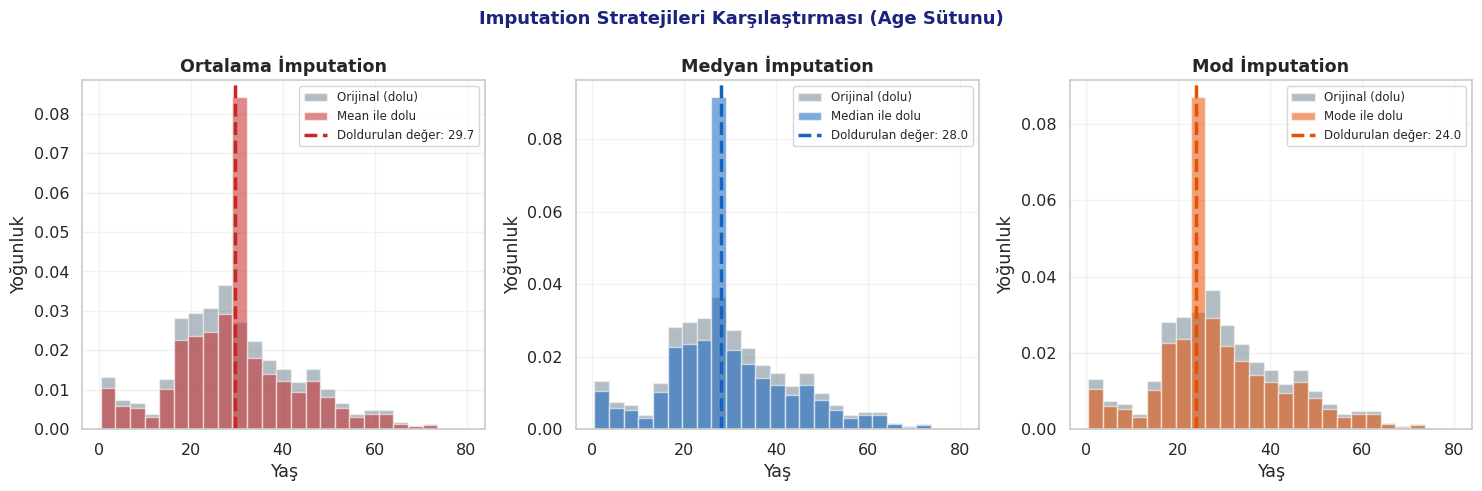

✅ Eksik değerler dolduruldu. Kalan eksik: 0


In [11]:
# ─────────────────────────────────────────────────────────────────
# DEMO 4.2: Eksik Değer Doldurma (Imputation) — Karşılaştırmalı
# Neden? → Farklı imputation stratejilerinin etkisini görmek için
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Imputation Stratejileri Karşılaştırması (Age Sütunu)',
             fontsize=13, fontweight='700', color=PAL['navy'])
age_original = df_clean['Age'].dropna()
strategies = [
    ('mean',   'Ortalama İmputation', PAL['red'],    df_clean['Age'].mean()),
    ('median', 'Medyan İmputation',   PAL['blue'],   df_clean['Age'].median()),
    ('mode',   'Mod İmputation',      PAL['orange'], df_clean['Age'].mode()[0]),
]
for ax, (strat, title, clr, fill_val) in zip(axes, strategies):
    age_imputed = df_clean['Age'].fillna(fill_val)
    # Orijinal dağılım
    ax.hist(age_original, bins=25, alpha=0.45, color=PAL['gray'],
            density=True, label='Orijinal (dolu)', edgecolor='white')
    # Doldurulmuş dağılım
    ax.hist(age_imputed, bins=25, alpha=0.55, color=clr,
            density=True, label=f'{strat.capitalize()} ile dolu', edgecolor='white')
    ax.axvline(fill_val, color=clr, lw=2.5, ls='--',
               label=f'Doldurulan değer: {fill_val:.1f}')
    ax.set_title(title, fontweight='600')
    ax.set_xlabel('Yaş'); ax.set_ylabel('Yoğunluk')
    ax.legend(fontsize=8.5)
plt.tight_layout()
plt.show()

# ── Uygulama: Medyan imputation (aykırı değerlere dayanıklı) ──
df_clean['Age']      = df_clean['Age'].fillna(df_clean['Age'].median())
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])
print(f'✅ Eksik değerler dolduruldu. Kalan eksik: {df_clean.isnull().sum().sum()}')

Bu görsel, veri setindeki eksik yaş (Age) değerlerinin üç farklı basit istatistiksel yöntemle doldurulmasının (imputation) verinin genel dağılımı üzerindeki etkisini karşılaştırmaktadır.

Grafiklerde **gri gölgeler** eksik veriler doldurulmadan önceki orijinal dağılımı, **renkli kısımlar** ise boşluklar doldurulduktan sonraki yeni dağılımı gösterir:

* **Ortalama (Mean) İmputation:** Eksik yaşlar, tüm yolcuların yaş ortalaması olan **29.7** ile doldurulmuştur. Bu durum, grafikte 30 yaş civarında doğal olmayan bir yığılma (kırmızı çizgi) yaratmıştır.
* **Medyan (Median) İmputation:** Eksik yaşlar, sıralanmış verinin tam ortasındaki değer olan **28.0** ile doldurulmuştur. Yığılma 28 yaşına (mavi çizgi) kaymıştır. (Aykırı değerlerden daha az etkilendiği için yaş gibi değişkenlerde genellikle bu yöntem tercih edilir).
* **Mod İmputation:** Eksik yaşlar, veri setinde en çok tekrar eden yaş olan **24.0** ile doldurulmuştur. Bu yöntem, 24 yaşında çok daha keskin ve uzun bir yığılmaya (turuncu çizgi) sebep olmuştur.

**Özetle:** Bu grafikler bize, eksik verileri tek bir sabit değerle doldurmanın modelin çalışmasını sağlasa da verinin doğal varyansını (çeşitliliğini) bozarak o noktada yapay bir tepe noktası oluşturduğunu açıkça göstermektedir.

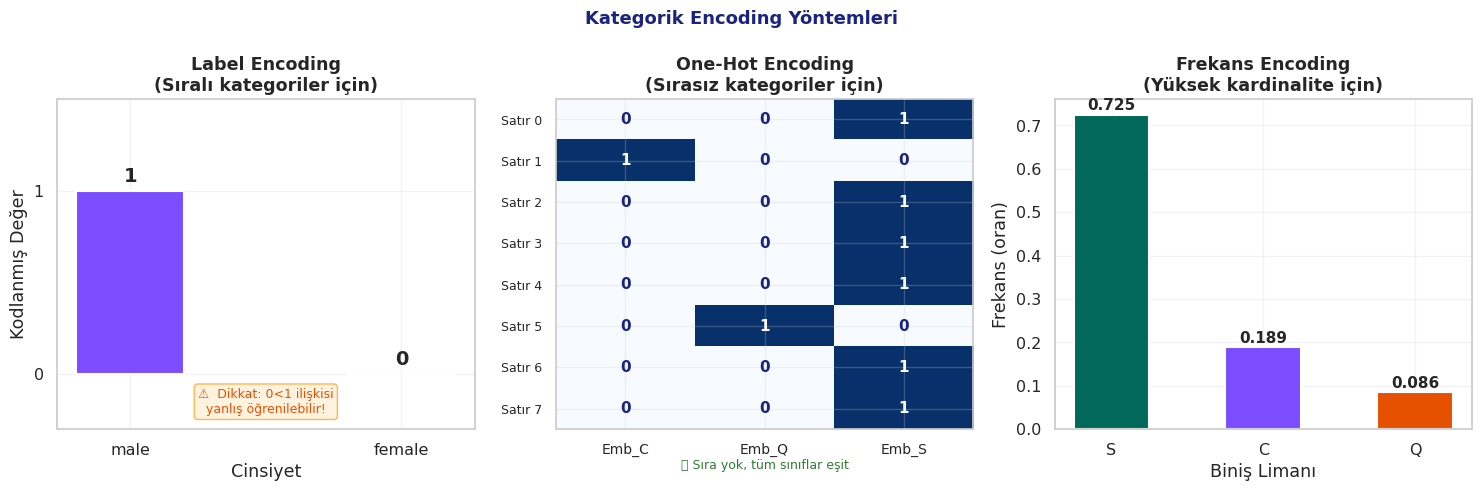

✅ Encoding tamamlandı. Sütunlar: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Emb_Q', 'Emb_S']


In [12]:
# ─────────────────────────────────────────────────────────────────
# DEMO 4.3: Encoding — Kategorik → Sayısal
# Neden? → Modeller matematiksel işlem yapar, metin değil
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Kategorik Encoding Yöntemleri', fontsize=13,
             fontweight='700', color=PAL['navy'])

# ── Label Encoding ────────────────────────────────────────────
ax = axes[0]
le = LabelEncoder()
sex_encoded = le.fit_transform(df_clean['Sex'])
mapping = dict(zip(df_clean['Sex'].unique(), le.transform(df_clean['Sex'].unique())))
cats_ = list(mapping.keys()); vals_ = [mapping[k] for k in cats_]
bars_ = ax.bar(cats_, vals_, color=[PAL['purple'], PAL['blue']],
               width=0.4, edgecolor='white', linewidth=1.5)
for b, v in zip(bars_, vals_):
    ax.text(b.get_x()+b.get_width()/2, v+0.05, str(v),
            ha='center', fontsize=14, fontweight='700')
ax.set_ylim(-0.3, 1.5); ax.set_yticks([0,1])
ax.set_title('Label Encoding\n(Sıralı kategoriler için)', fontweight='600')
ax.set_xlabel('Cinsiyet'); ax.set_ylabel('Kodlanmış Değer')
ax.text(0.5, 0.05, '⚠️  Dikkat: 0<1 ilişkisi\nyanlış öğrenilebilir!',
        transform=ax.transAxes, ha='center', fontsize=9,
        color=PAL['orange'],
        bbox=dict(boxstyle='round', fc='#FFF3E0', ec='#FFB74D'))

# ── One-Hot Encoding ─────────────────────────────────────────
ax = axes[1]
ohe = pd.get_dummies(df_clean['Embarked'], prefix='Emb')
sample = ohe.head(8).reset_index(drop=True)
im = ax.imshow(sample.values, cmap='Blues', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(ohe.columns)))
ax.set_xticklabels(ohe.columns, fontsize=10)
ax.set_yticks(range(len(sample)))
ax.set_yticklabels([f'Satır {i}' for i in range(len(sample))], fontsize=9)
for i in range(len(sample)):
    for j in range(len(ohe.columns)):
        ax.text(j, i, str(int(sample.values[i,j])),
                ha='center', va='center', fontsize=11,
                fontweight='bold',
                color='white' if sample.values[i,j] > 0.5 else PAL['navy'])
ax.set_title('One-Hot Encoding\n(Sırasız kategoriler için)', fontweight='600')
ax.text(0.5, -0.12, '✅ Sıra yok, tüm sınıflar eşit',
        transform=ax.transAxes, ha='center', fontsize=9, color=PAL['green'])

# ── Frekans Encoding ─────────────────────────────────────────
ax = axes[2]
freq_map = df_clean['Embarked'].value_counts(normalize=True)
ax.bar(freq_map.index, freq_map.values,
       color=[PAL['teal'], PAL['purple'], PAL['orange']],
       edgecolor='white', linewidth=1.5, width=0.5)
for i, (idx, val) in enumerate(freq_map.items()):
    ax.text(i, val+0.01, f'{val:.3f}', ha='center',
            fontsize=11, fontweight='700')
ax.set_title('Frekans Encoding\n(Yüksek kardinalite için)', fontweight='600')
ax.set_xlabel('Biniş Limanı'); ax.set_ylabel('Frekans (oran)')

plt.tight_layout()
plt.show()

# Uygulamalı encoding
df_clean['Sex'] = LabelEncoder().fit_transform(df_clean['Sex'])
emb_dummies = pd.get_dummies(df_clean['Embarked'], prefix='Emb', drop_first=True)
df_clean = pd.concat([df_clean.drop('Embarked', axis=1), emb_dummies], axis=1)
print('✅ Encoding tamamlandı. Sütunlar:', list(df_clean.columns))

Bu görsel, makine öğrenmesi modellerinin metin tabanlı (kategorik) verileri anlayabilmesi için bu verileri sayısal değerlere dönüştürürken kullanılan üç temel **kodlama (encoding)** yöntemini özetlemektedir.

Grafikteki yöntemlerin temel mantığı şu şekildedir:

* **Label Encoding (Sol Grafik):** Her farklı kategoriye sırayla bir tam sayı atanır (örneğin; female = 0, male = 1). Görselin altındaki uyarıda belirtildiği gibi, model bu sayıları matematiksel bir büyüklük-küçüklük ilişkisi (0 < 1) olarak yanlış anlayabilir. Bu nedenle genellikle sadece doğal bir sırası olan verilerde (örneğin; "kötü, orta, iyi" -> 0, 1, 2) kullanılması tavsiye edilir.
* **One-Hot Encoding (Orta Grafik):** Bir sütundaki her bir kategori için tabloya yeni bir sütun eklenir. Veri hangi kategoriye aitse o sütuna **1**, diğer sütunlara **0** yazılır. Kategoriler arasında hiçbir üstünlük veya sıralama olmadığında (sırasız kategoriler) en güvenli yöntemdir çünkü tüm sınıflara eşit davranır.
* **Frekans Encoding (Sağ Grafik):** Kategoriler rastgele sayılarla değil, tüm veri seti içinde görülme sıklıklarına (oranlarına) göre sayısallaştırılır (örneğin 'S' limanından binenlerin oranı 0.725). Kategori sayısının çok fazla olduğu durumlarda (One-Hot Encoding ile yüzlerce sütun oluşmasını engellemek için) tercih edilen pratik bir yöntemdir.

**Özetle:** Bu grafik, elimizdeki kategorik verinin yapısına (sıralı olup olmamasına veya çok fazla çeşitlilik içerip içermemesine) göre hangi sayısallaştırma yöntemini seçmemiz gerektiğini anlatan bir rehberdir.

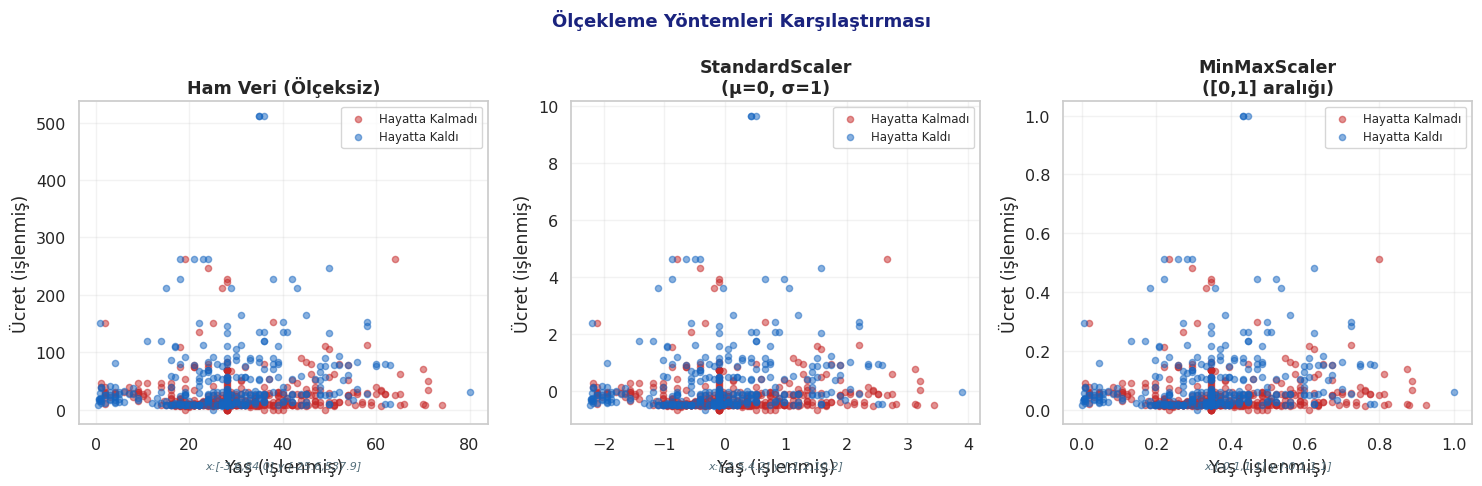

📌 StandardScaler: Özellikler merkeze çekiliyor, birim varyans
📌 MinMaxScaler:   Her şey [0,1] aralığına sıkıştırılıyor


In [13]:
# ─────────────────────────────────────────────────────────────────
# DEMO 4.4: Ölçekleme (Scaling) — Karşılaştırmalı
# Neden? → SVM, KNN, LR büyük sayılara duyarlı;
#          Ağaç modelleri duyarsız.
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Ölçekleme Yöntemleri Karşılaştırması',
             fontsize=13, fontweight='700', color=PAL['navy'])
X_raw = df_clean[['Age','Fare']].values
scalers = [
    (None,          'Ham Veri (Ölçeksiz)',    PAL['gray']),
    (StandardScaler(),'StandardScaler\n(μ=0, σ=1)', PAL['blue']),
    (MinMaxScaler(), 'MinMaxScaler\n([0,1] aralığı)', PAL['green']),
]
for ax, (scaler, title, clr) in zip(axes, scalers):
    X_plot = scaler.fit_transform(X_raw) if scaler else X_raw
    survived = df_clean['Survived'].values
    ax.scatter(X_plot[survived==0, 0], X_plot[survived==0, 1],
               c=PAL['red'], alpha=0.5, s=20, label='Hayatta Kalmadı')
    ax.scatter(X_plot[survived==1, 0], X_plot[survived==1, 1],
               c=PAL['blue'], alpha=0.5, s=20, label='Hayatta Kaldı')
    ax.set_title(title, fontweight='600')
    ax.set_xlabel('Yaş (işlenmiş)'); ax.set_ylabel('Ücret (işlenmiş)')
    ax.legend(fontsize=8.5)
    # Eksen aralığı bilgisi
    xlim = ax.get_xlim(); ylim = ax.get_ylim()
    ax.text(0.5, -0.14, f'x:[{xlim[0]:.1f},{xlim[1]:.1f}] y:[{ylim[0]:.1f},{ylim[1]:.1f}]',
            transform=ax.transAxes, ha='center', fontsize=8,
            color=PAL['gray'], style='italic')
plt.tight_layout()
plt.show()
print('📌 StandardScaler: Özellikler merkeze çekiliyor, birim varyans')
print('📌 MinMaxScaler:   Her şey [0,1] aralığına sıkıştırılıyor')

Bu görsel, makine öğrenmesi modellerini eğitmeden önce sayısal verileri aynı büyüklük seviyesine getirmek için uygulanan **Ölçekleme (Scaling)** işleminin veri üzerindeki etkisini göstermektedir.

Grafiklere bakıldığında göze çarpan en önemli detay; kırmızı ve mavi noktaların birbirlerine olan konumlarının ve veri kümesinin genel şeklinin üç grafikte de **birebir aynı kalmasıdır**. Değişen tek şey, eksenlerde yazan sayılardır:

* **Ham Veri (Sol Grafik):** Orijinal verilerdir. Yaş (x ekseni) 0-80, bilet ücreti (y ekseni) ise 0-500 aralığındadır. Eğer veriyi bu haliyle SVM veya KNN gibi uzaklık temelli bir modele verirsek, bilet ücretindeki sayılar matematiksel olarak daha büyük olduğu için model yaşı tamamen görmezden gelip sadece bilet ücretine odaklanma yanılgısına düşebilir.
* **StandardScaler (Orta Grafik):** Veriyi sıfır merkezli hale getirir (ortalama=0) ve standart sapmasını 1 yapar. Eksenlere dikkat edilirse, veriler genellikle -2 ile +4 gibi çok daha küçük, birbirine yakın ve dengeli bir aralığa oturtulmuştur.
* **MinMaxScaler (Sağ Grafik):** Her bir sütundaki en küçük değeri 0, en büyük değeri 1 kabul ederek tüm veriyi **istisnasız olarak [0, 1] aralığına** sıkıştırır. Eksenler 0.0 ile 1.0 arasındadır.

**Özetle:** Ölçekleme işlemi, verinin içindeki asıl ilişkiyi (hikâyeyi) bozmadan eksenleri hizalar. Bu sayede modeller, "Yaş" ve "Bilet Ücreti" gibi tamamen farklı birimlere ve büyüklüklere sahip özelliklerin her ikisine de adil ve eşit bir şekilde yaklaşarak doğru öğrenmeyi gerçekleştirir.

---
# BÖLÜM 5: Özellik Mühendisliği (Feature Engineering)
## ❓ Ne yapıyoruz?
Mevcut sütunlardan yeni, daha bilgi dolu sütunlar türetiyoruz.
## ❓ Neden yapıyoruz?
- Ham veri her zaman en iyi özellik değildir
- Domain bilgisi ile yeni değişkenler modeli güçlü kılar
- Örnek: `SibSp + Parch + 1 = FamilySize` daha anlamlı bir değişken
> **💡 Bu adım genellikle en fazla performans artışını sağlayan adımdır!**

✨ Oluşturulan Yeni Özellikler:
   FamilySize = SibSp + Parch + 1
   IsAlone    = FamilySize == 1
   AgeGroup   = Yaş grupları (Çocuk/Genç/...)
   FareBand   = Bilet ücreti dilimleri (4 eşit grup)
   Title      = İsimden unvan çıkarma (Mr/Mrs/Miss/...)


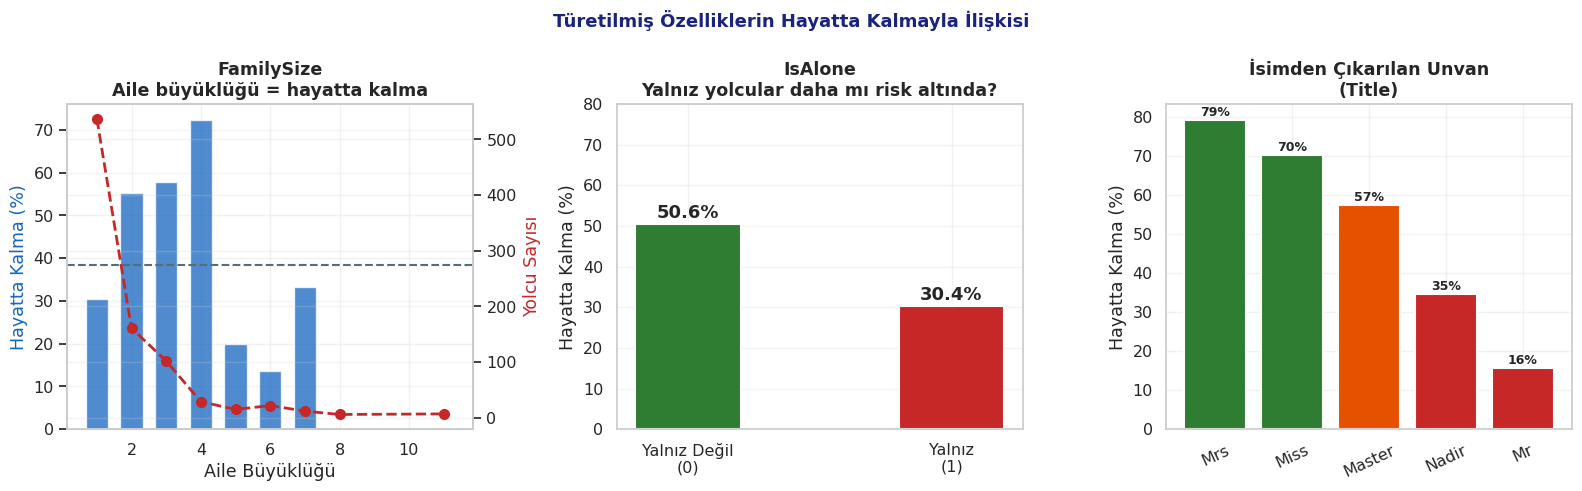

📌 Yalnız yolcular %30 oranında hayatta kalıyor
📌 Mrs ve Miss unvanları çok yüksek hayatta kalma oranına sahip


In [14]:
# ─────────────────────────────────────────────────────────────────
# DEMO 5.1: Yeni Özellik Üretimi & Etkisi
# Neden? → Domain bilgisiyle modeli güçlendirmek
# ─────────────────────────────────────────────────────────────────
df_feat = df_clean.copy()

# ── Yeni özellikler ──────────────────────────────────────────────
df_feat['FamilySize'] = df_feat['SibSp'] + df_feat['Parch'] + 1
df_feat['IsAlone']    = (df_feat['FamilySize'] == 1).astype(int)
df_feat['AgeGroup']   = pd.cut(df_feat['Age'],
                                bins=[0,12,18,35,60,100],
                                labels=['Çocuk','Genç','YetişkinG','YetişkinO','Yaşlı'])
df_feat['FareBand']   = pd.qcut(df_feat['Fare'], q=4,
                                 labels=['Düşük','Orta','Yüksek','ÇokYüksek'])
df_feat['Title']      = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df_feat['Title']      = df_feat['Title'].replace(
    ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'],
    'Nadir').replace({'Mlle':'Miss','Ms':'Miss','Mme':'Mrs'})

print('✨ Oluşturulan Yeni Özellikler:')
print('   FamilySize = SibSp + Parch + 1')
print('   IsAlone    = FamilySize == 1')
print('   AgeGroup   = Yaş grupları (Çocuk/Genç/...)')
print('   FareBand   = Bilet ücreti dilimleri (4 eşit grup)')
print('   Title      = İsimden unvan çıkarma (Mr/Mrs/Miss/...)')

# ── Görsel: Yeni özelliklerin etkisi ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Türetilmiş Özelliklerin Hayatta Kalmayla İlişkisi',
             fontsize=13, fontweight='700', color=PAL['navy'])

# FamilySize
ax = axes[0]
fs_surv = df_feat.groupby('FamilySize')['Survived'].agg(['mean','count'])
fs_surv['mean'] *= 100
ax2 = ax.twinx()
bars = ax.bar(fs_surv.index, fs_surv['mean'], color=PAL['blue'],
              alpha=0.75, width=0.65, label='Hayatta Kalma %')
ax2.plot(fs_surv.index, fs_surv['count'], 'o--', color=PAL['red'],
         lw=2, ms=7, label='Yolcu Sayısı')
ax.set_xlabel('Aile Büyüklüğü'); ax.set_ylabel('Hayatta Kalma (%)', color=PAL['blue'])
ax2.set_ylabel('Yolcu Sayısı', color=PAL['red'])
ax.set_title('FamilySize\nAile büyüklüğü = hayatta kalma', fontweight='600')
ax.axhline(df_feat['Survived'].mean()*100, color=PAL['gray'], lw=1.5, ls='--')

# IsAlone
ax = axes[1]
alone_surv = df_feat.groupby('IsAlone')['Survived'].mean() * 100
bars2 = ax.bar(['Yalnız Değil\n(0)', 'Yalnız\n(1)'],
               alone_surv.values,
               color=[PAL['green'], PAL['red']],
               width=0.4, edgecolor='white', linewidth=1.5)
for b, v in zip(bars2, alone_surv.values):
    ax.text(b.get_x()+b.get_width()/2, v+1.5, f'{v:.1f}%',
            ha='center', fontsize=13, fontweight='700')
ax.set_ylim(0, 80); ax.set_ylabel('Hayatta Kalma (%)')
ax.set_title('IsAlone\nYalnız yolcular daha mı risk altında?', fontweight='600')

# Title
ax = axes[2]
if 'Title' in df_feat.columns:
    title_surv = (df_feat.groupby('Title')['Survived']
                  .mean().sort_values(ascending=False) * 100)
    colors_t = [PAL['green'] if v > 60 else PAL['orange'] if v > 40 else PAL['red']
                for v in title_surv.values]
    bars3 = ax.bar(title_surv.index, title_surv.values, color=colors_t,
                   edgecolor='white', linewidth=1.5)
    for b, v in zip(bars3, title_surv.values):
        ax.text(b.get_x()+b.get_width()/2, v+1, f'{v:.0f}%',
                ha='center', fontsize=9, fontweight='700')
    ax.set_ylabel('Hayatta Kalma (%)')
    ax.set_title('İsimden Çıkarılan Unvan\n(Title)', fontweight='600')
    ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()
print('📌 Yalnız yolcular %30 oranında hayatta kalıyor')
print('📌 Mrs ve Miss unvanları çok yüksek hayatta kalma oranına sahip')

Bu görsel, makine öğrenmesi sürecindeki en kritik ve yaratıcı adımlardan biri olan **Özellik Mühendisliği (Feature Engineering)** aşamasının modele nasıl güç kattığını göstermektedir. Ham verilerdeki mevcut sütunları birleştirerek veya içlerinden metin ayıklayarak türetilen *yeni* değişkenlerin, hayatta kalma durumuyla nasıl daha net ilişkiler kurduğunu inceliyor.

Grafiklerden çıkarılabilecek temel bulgular şunlardır:

* **Aile Büyüklüğü (FamilySize) ve Yalnızlık Durumu (IsAlone):** Sol ve orta grafik, yolcuların kardeş/eş ve ebeveyn/çocuk sayılarının birleştirilmesiyle oluşturulan yeni özellikleri inceliyor.
    * Tamamen **yalnız** seyahat edenlerin hayatta kalma şansı oldukça düşüktür (%30.4).
    * Çok **kalabalık ailelerin** (5 kişi ve üzeri) hayatta kalma oranları dibe çakılmaktadır (tahliye sırasında tüm aileyi bir araya getirip kurtulmak çok daha zor olduğu için).
    * Ancak **2 ila 4 kişilik küçük aileler**, tahliye sürecinde birbirlerine yardım edebildikleri için %50-70 bandında en yüksek hayatta kalma oranına ulaşmışlardır.
* **İsimden Çıkarılan Unvan (Title):** Sağ grafik, karmaşık metinlerden oluşan "İsim" sütununun atılmak yerine içindeki "Mr, Mrs, Miss" gibi unvanların çekip çıkarılmasıyla elde edilen harika bir özelliği gösteriyor. "Mrs" (Evli kadınlar - %79) ve "Miss" (Bekâr kadınlar - %70) en yüksek orana sahipken, erkek çocukları temsil eden "Master" unvanı da %57 ile öncelikli kurtarılanlar arasında olduklarını kanıtlıyor. Yetişkin erkekleri temsil eden "Mr" ise %16 ile listenin en sonunda.

**Özetle:** Ham verilerde dağınık halde bulunan bilgiler, özellik mühendisliği ile anlamlı başlıklar (yalnız mı?, aile boyu ne?, sosyal statüsü/yaş grubu ne?) altında toplandığında, makine öğrenmesi modelinin "kimin hayatta kalacağını" anlaması çok daha kolay hale gelmektedir.

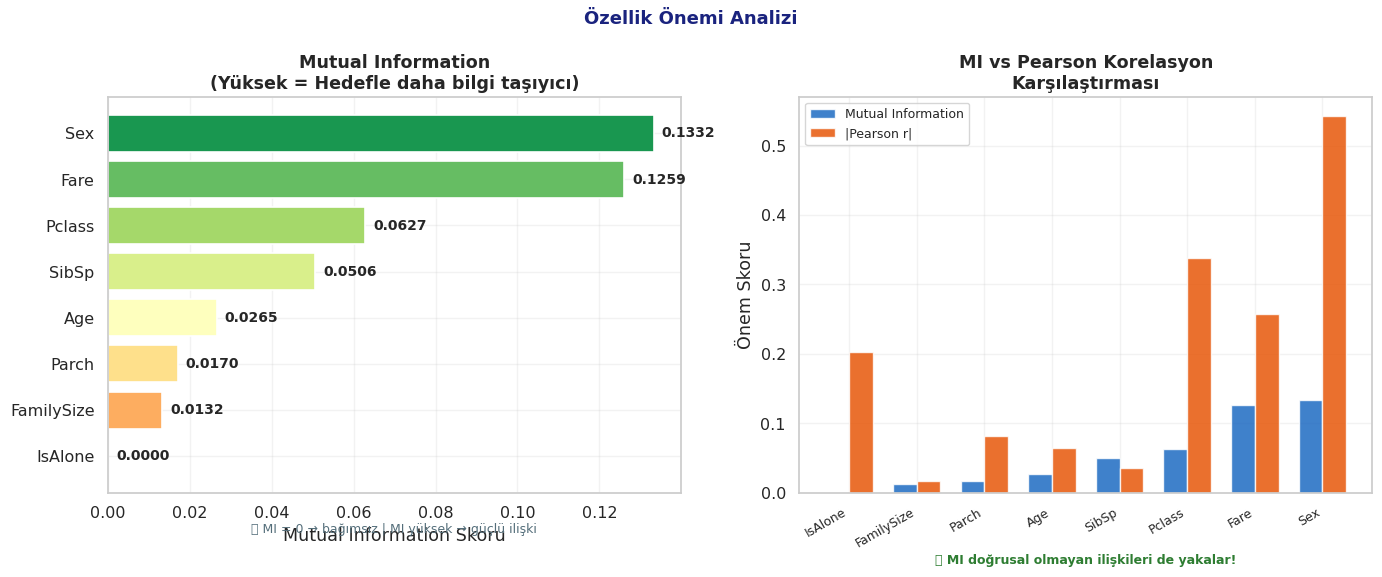

In [15]:
# ─────────────────────────────────────────────────────────────────
# DEMO 5.2: Özellik Önemi (Model'den Bağımsız — Mutual Information)
# Neden? → Hangi özellikler hedef değişkeni en iyi açıklıyor?
# ─────────────────────────────────────────────────────────────────
# Final özellik seti hazırla
feature_cols = ['Pclass','Sex','Age','SibSp','Parch','Fare','FamilySize','IsAlone']
X_fi = df_feat[feature_cols].copy()
y_fi = df_feat['Survived']

# Mutual Information Skorları
mi_scores = mutual_info_classif(X_fi, y_fi, random_state=42)
mi_df = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Özellik Önemi Analizi', fontsize=13,
             fontweight='700', color=PAL['navy'])

# MI Skorları
ax = axes[0]
colors_mi = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(mi_df)))
bars = ax.barh(mi_df.index, mi_df.values, color=colors_mi,
               edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, mi_df.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='600')
ax.set_xlabel('Mutual Information Skoru')
ax.set_title('Mutual Information\n(Yüksek = Hedefle daha bilgi taşıyıcı)',
             fontweight='600')
ax.text(0.5, -0.1, '💡 MI = 0 → bağımsız | MI yüksek → güçlü ilişki',
        transform=ax.transAxes, ha='center', fontsize=9, color=PAL['gray'])

# Korelasyon + MI karşılaştırma
ax = axes[1]
corr_abs = X_fi.corrwith(y_fi).abs().reindex(mi_df.index)
x_pos = np.arange(len(mi_df))
w = 0.35
ax.bar(x_pos - w/2, mi_df.values, w, label='Mutual Information',
       color=PAL['blue'], alpha=0.82, edgecolor='white')
ax.bar(x_pos + w/2, corr_abs.values, w, label='|Pearson r|',
       color=PAL['orange'], alpha=0.82, edgecolor='white')
ax.set_xticks(x_pos)
ax.set_xticklabels(mi_df.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Önem Skoru')
ax.set_title('MI vs Pearson Korelasyon\nKarşılaştırması', fontweight='600')
ax.legend(fontsize=9)
ax.text(0.5, -0.18, '📌 MI doğrusal olmayan ilişkileri de yakalar!',
        transform=ax.transAxes, ha='center', fontsize=9,
        color=PAL['green'], fontweight='600')
plt.tight_layout()
plt.show()

Bu görsel, veri setindeki özelliklerin (sütunların) hedefi (hayatta kalmayı) tahmin etmede ne kadar yararlı olduğunu **modelden bağımsız istatistiksel yöntemlerle** değerlendiren "Özellik Önemi" analizidir.

Tablo, değişkenleri iki farklı yaklaşımla değerlendirmektedir:

* **Sol Grafik (Mutual Information - Karşılıklı Bilgi):** Bir özelliğin hedef değişken hakkında tek başına ne kadar bilgi taşıdığını (belirsizliği ne kadar azalttığını) gösterir. Skor ne kadar yüksekse, özellik o kadar değerlidir. Burada **Cinsiyet (Sex)** ve **Bilet Ücreti (Fare)** hedefe giden yolda en fazla bilgi taşıyan, yani tahminde en çok işe yarayacak özellikler olarak zirvede yer alıyor.
* **Sağ Grafik (MI vs Pearson Karşılaştırması):** Doğrusal ilişkiyi ölçen standart Pearson Korelasyonu (turuncu çubuklar) ile Mutual Information skorlarını (mavi çubuklar) yan yana koyar. Grafiğin altındaki yeşil notun da vurguladığı gibi en önemli fark şudur: Pearson korelasyonu sadece düz (doğrusal) orantıları yakalayabilirken, **Mutual Information doğrusal olmayan, çok daha karmaşık ve gizli ilişkileri de tespit edebilir.**

**Özetle:** Makine öğrenmesi algoritmalarını eğitmeden önce hangi özelliklerin modeli besleyecek "gerçek ve temiz bilgiye" sahip olduğunu anlamak için bu tür analizler kullanılır. Cinsiyet, bilet ücreti ve yolcu sınıfı (Pclass), bu veri setinin belkemiğini oluşturan en güçlü üç değişkendir.

---
# BÖLÜM 6: Model Seçimi & Eğitim
## ❓ Ne yapıyoruz?
Birden fazla model deneyip performanslarını karşılaştırıyoruz.
## ❓ Neden yapıyoruz?
- Her algoritmanın güçlü ve zayıf yönü vardır
- Hangi modelin veriye uyduğunu önceden bilemeyiz → **dene ve karşılaştır**
- Cross-validation ile güvenilir tahmin yaparız
## 🔀 Train / Test Split Neden?
```
Tüm veriyle eğit + test → Model veriyi "ezberlemiş" olabilir → Overfitting!
Test seti = Modelin hiç görmediği veri → Gerçek performans göstergesi
```

📊 Veri Bölümü:
   Tüm veri  :  891 örnek
   Eğitim    :  712 örnek (%80)
   Test      :  179 örnek (%20)

🎯 Sınıf Dengesi:
   Eğitim → 0:439 | 1:273
   Test   → 0:110  | 1:69


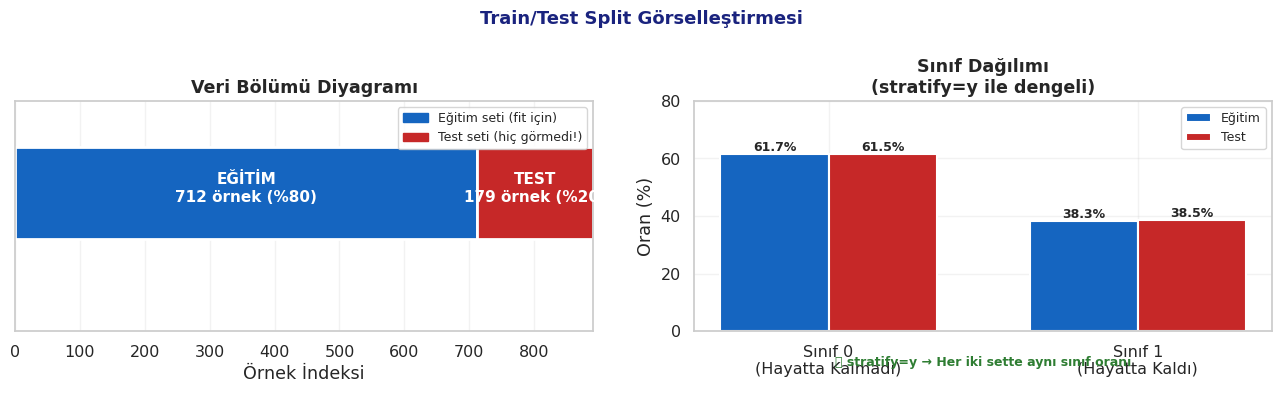

In [16]:
# ─────────────────────────────────────────────────────────────────
# DEMO 6.1: Train/Test Split Görselleştirmesi
# Neden? → Veri bölümünü somutlaştırmak için
# ─────────────────────────────────────────────────────────────────
feature_cols = ['Pclass','Sex','Age','SibSp','Parch','Fare','FamilySize','IsAlone']
X = df_feat[feature_cols].copy()
y = df_feat['Survived']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

# Ölçekleme
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit + transform
X_test_s  = scaler.transform(X_test)         # sadece transform (data leakage önleme!)

print(f'📊 Veri Bölümü:')
print(f'   Tüm veri  : {len(X):>4} örnek')
print(f'   Eğitim    : {len(X_train):>4} örnek (%{len(X_train)/len(X)*100:.0f})')
print(f'   Test      : {len(X_test):>4} örnek (%{len(X_test)/len(X)*100:.0f})')
print(f'\n🎯 Sınıf Dengesi:')
print(f'   Eğitim → 0:{(y_train==0).sum()} | 1:{(y_train==1).sum()}')
print(f'   Test   → 0:{(y_test==0).sum()}  | 1:{(y_test==1).sum()}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Train/Test Split Görselleştirmesi', fontsize=13,
             fontweight='700', color=PAL['navy'])

# Bölüm diyagramı
ax = axes[0]
total = len(X)
ax.broken_barh([(0, len(X_train))], (0.4, 0.4),
               facecolors=PAL['blue'], edgecolor='white', linewidth=2)
ax.broken_barh([(len(X_train), len(X_test))], (0.4, 0.4),
               facecolors=PAL['red'], edgecolor='white', linewidth=2)
ax.text(len(X_train)/2, 0.62, f'EĞİTİM\n{len(X_train)} örnek (%80)',
        ha='center', va='center', fontsize=11, fontweight='700', color='white')
ax.text(len(X_train) + len(X_test)/2, 0.62, f'TEST\n{len(X_test)} örnek (%20)',
        ha='center', va='center', fontsize=11, fontweight='700', color='white')
ax.set_xlim(0, total); ax.set_ylim(0, 1)
ax.set_xlabel('Örnek İndeksi'); ax.set_yticks([])
ax.set_title('Veri Bölümü Diyagramı', fontweight='600')
patches = [mpatches.Patch(color=PAL['blue'], label='Eğitim seti (fit için)'),
           mpatches.Patch(color=PAL['red'],  label='Test seti (hiç görmedi!)')]
ax.legend(handles=patches, fontsize=9, loc='upper right')

# Stratify: Sınıf dengesi
ax = axes[1]
train_dist = y_train.value_counts(normalize=True) * 100
test_dist  = y_test.value_counts(normalize=True) * 100
x_ = np.arange(2); w = 0.35
ax.bar(x_-w/2, train_dist.values, w, label='Eğitim',
       color=PAL['blue'], edgecolor='white', linewidth=1.5)
ax.bar(x_+w/2, test_dist.values,  w, label='Test',
       color=PAL['red'],  edgecolor='white', linewidth=1.5)
ax.set_xticks(x_); ax.set_xticklabels(['Sınıf 0\n(Hayatta Kalmadı)',
                                        'Sınıf 1\n(Hayatta Kaldı)'])
ax.set_ylabel('Oran (%)'); ax.set_ylim(0, 80)
ax.set_title('Sınıf Dağılımı\n(stratify=y ile dengeli)', fontweight='600')
ax.legend(fontsize=9)
ax.text(0.5, -0.15, '✅ stratify=y → Her iki sette aynı sınıf oranı',
        transform=ax.transAxes, ha='center', fontsize=9, color=PAL['green'],
        fontweight='600')
for cont in ax.containers:
    ax.bar_label(cont, fmt='%.1f%%', fontsize=9, fontweight='600')
plt.tight_layout()
plt.show()

Bu görsel, makine öğrenmesinde en temel prensiplerden biri olan **Eğitim (Train) ve Test Seti Ayrımını** açıklamaktadır.

Modelin sadece ezberlemediğini, gerçekten öğrendiğini kanıtlayabilmek için tüm veriyi aynı anda kullanmayız. Görsel bu süreci iki grafikle anlatıyor:

* **Sol Grafik (Veri Bölümü Diyagramı):** Elimizdeki toplam 891 yolcu verisinin nasıl bölündüğünü gösteriyor. Verinin **%80'i (712 örnek - mavi alan)** modeli eğitmek, yani kuralları bulmasını sağlamak için ayrılmıştır. Geriye kalan **%20'lik kısım (179 örnek - kırmızı alan)** ise modelden tamamen saklanır ve en sonda başarısını ölçmek (sınav yapmak) için kullanılır.
* **Sağ Grafik (Sınıf Dağılımı):** Veriyi %80-%20 bölerken rastgele bir kesim yapmanın tehlikeli olabileceğini gösteriyor. Örneğin, şans eseri tüm hayatta kalanlar eğitim setine düşerse model test setinde bocalayacaktır. Grafikteki barlar, `stratify` (tabakalandırma) yöntemi sayesinde hem eğitim hem de test setinde "Hayatta Kalan" (Sınıf 1) ve "Hayatta Kalamayan" (Sınıf 0) yolcu **oranlarının birbirine eşitlendiğini** kanıtlıyor (örneğin Sınıf 0 oranı eğitim setinde %61.7, test setinde %61.5).

**Özetle:** Bu görsel, adil bir model değerlendirmesi yapabilmek için verinin bir kısmının "görülmeyen sınav sorusu" olarak ayrılması gerektiğini ve bu ayrımın sınıflar arasındaki dengeyi bozmadan yapıldığını anlatmaktadır.

In [17]:
# ─────────────────────────────────────────────────────────────────
# DEMO 6.2: Çoklu Model Eğitimi & Cross-Validation Karşılaştırması
# Neden? → Hangi algoritma bu veriye en uygun? Tek test yanıltabilir!
#          CV = birden fazla test setinde ortalama performans
# ─────────────────────────────────────────────────────────────────
models = {
    'Lojistik Regresyon':  LogisticRegression(max_iter=1000, random_state=42),
    'Karar Ağacı':         DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)':           SVC(kernel='rbf', probability=True, random_state=42),
    'K-NN (k=5)':          KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes':         GaussianNB(),
}
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('⏳ Cross-Validation eğitimi başladı (5-Fold)...')
print('─'*55)
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_s, y_train, cv=cv,
                                scoring='accuracy', n_jobs=-1)
    model.fit(X_train_s, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test_s))
    results[name] = {
        'cv_mean':  cv_scores.mean(),
        'cv_std':   cv_scores.std(),
        'test_acc': test_acc,
        'model':    model,
        'cv_scores':cv_scores,
    }
    print(f'  {name:<25} CV: {cv_scores.mean():.3f}±{cv_scores.std():.3f}  '
          f'Test: {test_acc:.3f}')
print('\n✅ Tüm modeller eğitildi!')

⏳ Cross-Validation eğitimi başladı (5-Fold)...
───────────────────────────────────────────────────────
  Lojistik Regresyon        CV: 0.795±0.024  Test: 0.816
  Karar Ağacı               CV: 0.816±0.020  Test: 0.754
  Random Forest             CV: 0.809±0.021  Test: 0.821
  Gradient Boosting         CV: 0.826±0.035  Test: 0.799
  SVM (RBF)                 CV: 0.827±0.016  Test: 0.827
  K-NN (k=5)                CV: 0.815±0.029  Test: 0.821
  Naive Bayes               CV: 0.792±0.030  Test: 0.777

✅ Tüm modeller eğitildi!



🏆 En İyi Model: SVM (RBF)
   CV Doğruluk: 0.827 ± 0.016
   Test Doğruluk: 0.827


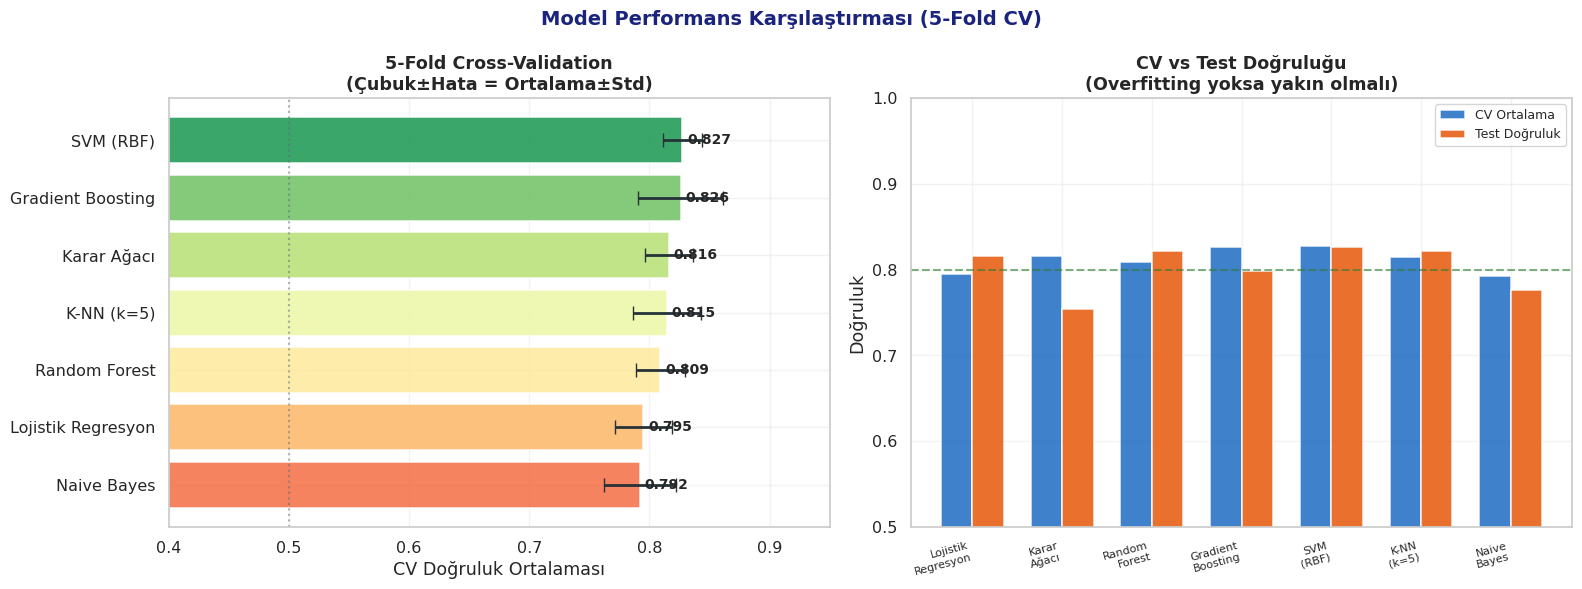

In [18]:
# ─────────────────────────────────────────────────────────────────
# DEMO 6.3: Model Karşılaştırma Görselleştirmesi
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Performans Karşılaştırması (5-Fold CV)',
             fontsize=14, fontweight='700', color=PAL['navy'])
names   = list(results.keys())
cv_means= [results[n]['cv_mean']  for n in names]
cv_stds = [results[n]['cv_std']   for n in names]
test_acc= [results[n]['test_acc'] for n in names]

# CV performans + hata barı
ax = axes[0]
sorted_idx = np.argsort(cv_means)
names_s    = [names[i] for i in sorted_idx]
cv_s       = [cv_means[i] for i in sorted_idx]
std_s      = [cv_stds[i] for i in sorted_idx]
colors_m   = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(names)))
bars = ax.barh(names_s, cv_s, color=colors_m, edgecolor='white',
               linewidth=1.2, alpha=0.85)
ax.errorbar(cv_s, range(len(names_s)), xerr=std_s,
            fmt='none', color='#263238', lw=2.0, capsize=5)
for bar, val in zip(bars, cv_s):
    ax.text(val + 0.004, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10, fontweight='700')
ax.axvline(0.5, color=PAL['gray'], lw=1.5, ls=':', alpha=0.5)
ax.set_xlabel('CV Doğruluk Ortalaması')
ax.set_title('5-Fold Cross-Validation\n(Çubuk±Hata = Ortalama±Std)',
             fontweight='600')
ax.set_xlim(0.4, 0.95)

# CV vs Test karşılaştırması
ax = axes[1]
x_  = np.arange(len(names))
w   = 0.35
b1  = ax.bar(x_-w/2, cv_means, w, label='CV Ortalama',
             color=PAL['blue'], alpha=0.82, edgecolor='white', linewidth=1.2)
b2  = ax.bar(x_+w/2, test_acc, w, label='Test Doğruluk',
             color=PAL['orange'], alpha=0.82, edgecolor='white', linewidth=1.2)
ax.set_xticks(x_)
ax.set_xticklabels([n.replace(' ', '\n') for n in names],
                    fontsize=8, rotation=15, ha='right')
ax.set_ylabel('Doğruluk')
ax.set_ylim(0.5, 1.0)
ax.set_title('CV vs Test Doğruluğu\n(Overfitting yoksa yakın olmalı)',
             fontweight='600')
ax.legend(fontsize=9)
ax.axhline(0.8, color=PAL['green'], lw=1.5, ls='--', alpha=0.6,
           label='%80 eşiği')

# En iyi modeli belirle
best_name = max(results, key=lambda n: results[n]['cv_mean'])
print(f'\n🏆 En İyi Model: {best_name}')
print(f'   CV Doğruluk: {results[best_name]["cv_mean"]:.3f} ± {results[best_name]["cv_std"]:.3f}')
print(f'   Test Doğruluk: {results[best_name]["test_acc"]:.3f}')
plt.tight_layout()
plt.show()

Bu görsel, eğittiğimiz 7 farklı makine öğrenmesi modelinin performanslarını birbiriyle yarıştırdığımız **"Model Karşılaştırma ve Seçim"** aşamasını özetlemektedir.

Grafiklerden çıkarılabilecek temel sonuçlar şunlardır:

* **Sol Grafik (Ortalama Eğitim Başarısı):** Modellerin çapraz doğrulama (Cross-Validation) yöntemiyle elde edilen ortalama doğruluk oranlarını gösteriyor. En üstte yer alan **SVM (RBF)** ve **Gradient Boosting** yaklaşık **%82.7**'lik başarı oranlarıyla en iyi modeller olarak öne çıkıyor. Çubukların ucundaki siyah çizgilerin (hata paylarının) dar olması, modellerin farklı veri parçalarında da istikrarlı tahminler yaptığını gösteriyor.
* **Sağ Grafik (Öğrenme vs. Ezberleme Kontrolü):** Modellerin eğitim esnasındaki başarıları (mavi çubuklar) ile daha önce hiç görmedikleri test setindeki "gerçek sınav" başarılarını (turuncu çubuklar) kıyaslıyor. Eğer mavi çubuk çok yüksek, turuncu çubuk çok düşük olsaydı modelin veriyi ezberlediğini (overfitting) söylerdik. Ancak burada iki çubuğun boyları birbirine çok yakın; bu da modellerin başarılı bir şekilde **genelleme yapabildiğini ve ezberlemediğini** kanıtlıyor. (Sadece Karar Ağacı modelinde ufak bir ezberleme belirtisi göze çarpıyor).

**Özetle:** Bu analiz, eldeki veri seti için tahminde bulunurken kullanılabilecek en başarılı, istikrarlı ve güvenilir algoritmaların SVM ve Gradient Boosting olduğunu istatistiksel olarak ispatlamaktadır.

---
# BÖLÜM 7: Model Değerlendirmesi
## ❓ Ne yapıyoruz?
Modelimizin "doğru" ve "yanlış" tahminlerini ayrıntılı analiz ediyoruz.
## ❓ Neden sadece doğruluk (%accuracy) yetmez?
```
Örnek: 1000 kişiden 950'si hasta değilse,
       Tüm tahminleri "hasta değil" yapan model → %95 doğruluk!
       Ama hasta kişileri hiç bulamıyor → Berbat model!
Çözüm: Precision, Recall, F1, ROC-AUC
```
## 📊 Metrik Sözlüğü
| Metrik | Formül | Ne anlama gelir? |
|--------|--------|-----------------|
| **Precision** | TP/(TP+FP) | Pozitif dediğimin ne kadarı gerçekten pozitif? |
| **Recall** | TP/(TP+FN) | Gerçek pozitiflerin ne kadarını bulabildim? |
| **F1** | 2·P·R/(P+R) | Precision ve Recall'un harmonik ortalaması |
| **ROC-AUC** | Alan altı alan | Tüm eşik değerleri için genel performans |

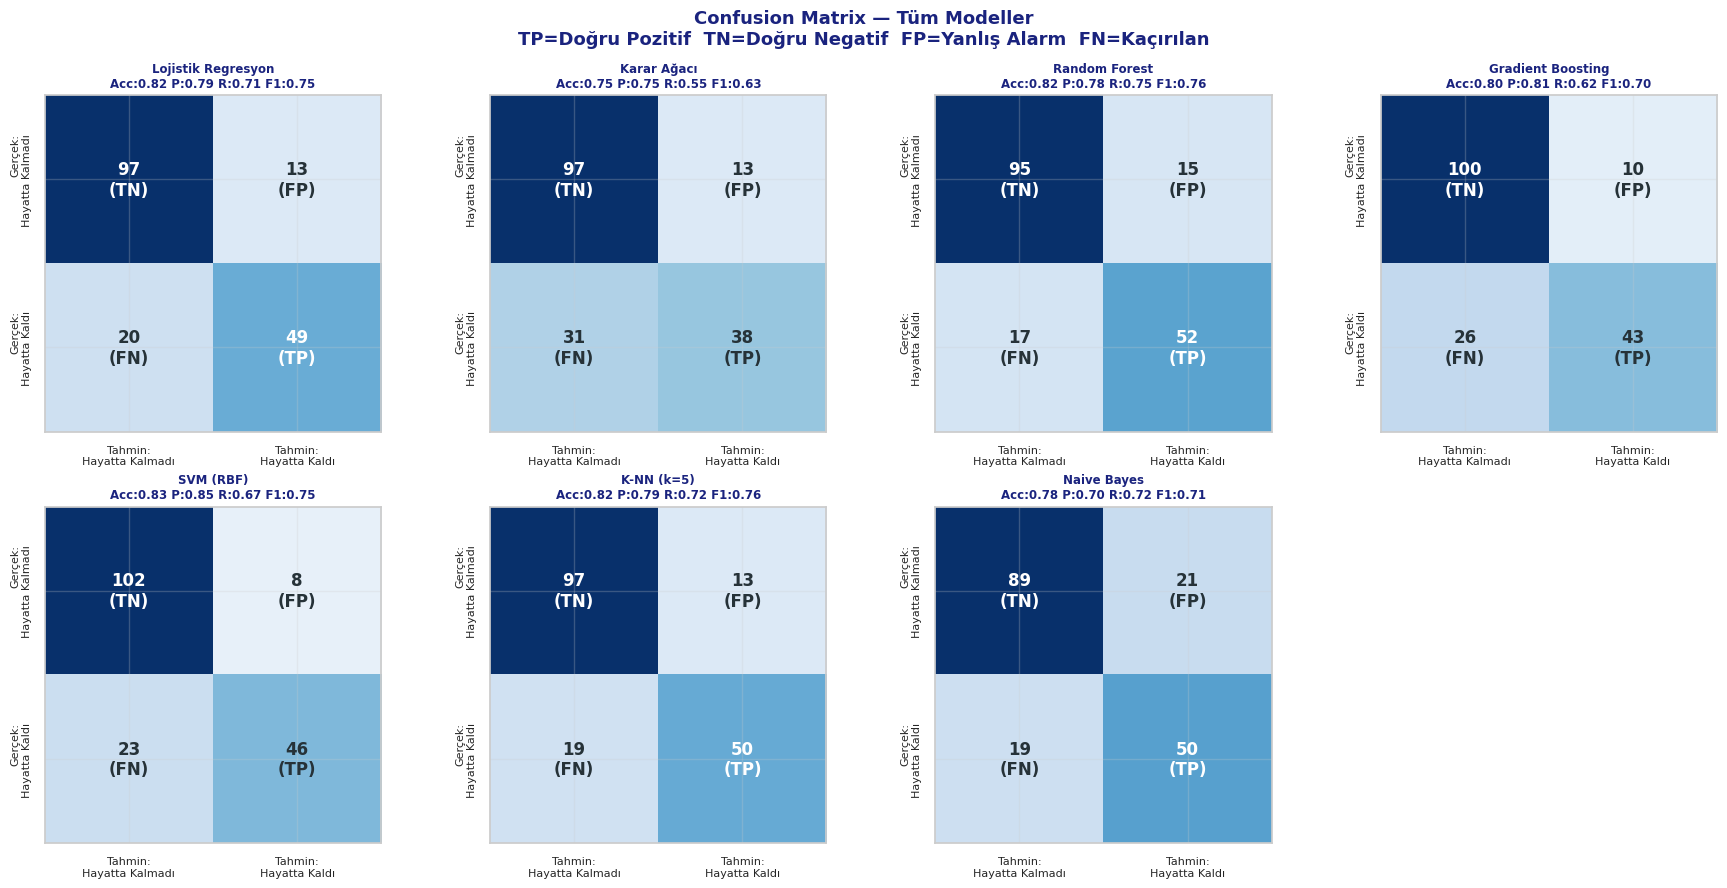

In [19]:
# ─────────────────────────────────────────────────────────────────
# DEMO 7.1: Confusion Matrix — Tüm Modeller
# Neden? → TP/FP/TN/FN'i görselleştirmek için
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Confusion Matrix — Tüm Modeller\n'
             'TP=Doğru Pozitif  TN=Doğru Negatif  FP=Yanlış Alarm  FN=Kaçırılan',
             fontsize=13, fontweight='700', color=PAL['navy'])
axes[-1, -1].set_visible(False)
for ax, (name, res) in zip(axes.flat, results.items()):
    cm = confusion_matrix(y_test, res['model'].predict(X_test_s))
    tn, fp, fn, tp = cm.ravel()
    im = ax.imshow(cm, cmap='Blues', vmin=0)
    for i in range(2):
        for j in range(2):
            label = ['TN','FP','FN','TP'][i*2+j]
            color_txt = 'white' if cm[i,j] > cm.max()/2 else '#263238'
            ax.text(j, i, f'{cm[i,j]}\n({label})',
                    ha='center', va='center', fontsize=12,
                    fontweight='700', color=color_txt)
    ax.set_xticks([0,1])
    ax.set_xticklabels(['Tahmin:\nHayatta Kalmadı', 'Tahmin:\nHayatta Kaldı'], fontsize=8)
    ax.set_yticks([0,1])
    ax.set_yticklabels(['Gerçek:\nHayatta Kalmadı', 'Gerçek:\nHayatta Kaldı'],
                        fontsize=8, rotation=90, va='center')
    acc = (tp+tn)/(tp+tn+fp+fn)
    prec = tp/(tp+fp) if (tp+fp) > 0 else 0
    rec  = tp/(tp+fn) if (tp+fn) > 0 else 0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0
    ax.set_title(f'{name[:22]}\nAcc:{acc:.2f} P:{prec:.2f} R:{rec:.2f} F1:{f1:.2f}',
                 fontsize=8.5, fontweight='600', color=PAL['navy'])
plt.tight_layout()
plt.show()

Bu görsel, modellerimizin sadece ne kadar doğru bildiğini değil, **hataları tam olarak nerede yaptığını** gösteren bir **Hata Matrisi (Confusion Matrix)** analizidir. Sadece tek bir genel doğruluk oranına (% Accuracy) bakmanın yetmediği durumlarda verinin röntgenini çeker.

Matristeki her bir kutunun (ve renklerin) Titanic örneğimizdeki anlamı şudur:

* **TN (Koyu Mavi - Sol Üst): Doğru Negatif.** Gerçekte hayatını kaybeden ve modelin de doğru bir şekilde "hayatını kaybetti" dediği kişiler. Modellerin neredeyse tamamı bu grupta çok başarılıdır (Örn: SVM burada 102 kişiyi doğru bilmiştir).
* **TP (Orta Mavi - Sağ Alt): Doğru Pozitif.** Gerçekte kurtulan ve modelin de başarıyla "kurtuldu" diye bildiği kişiler.
* **FP (Açık Renk - Sağ Üst): Yanlış Alarm.** Gerçekte hayatını kaybeden ama modelin yanlışlıkla *kurtuldu* zannettiği kişiler.
* **FN (Açık Renk - Sol Alt): Kaçırılanlar.** Gerçekte kurtulan ama modelin gözden kaçırıp *hayatını kaybetti* zannettiği kişiler.

**Grafiklerden Çıkarılacak Temel Sonuçlar:**
1.  **Dengesiz Öğrenme:** Modellerin hepsi "hayatını kaybedenleri" (TN) bulmada çok iyiyken, "kurtulanları" (TP) bulmada biraz zorlanıyor. Gözden kaçırılan kurtulanların (FN) sayısı, yanlış alarm sayısına (FP) göre daha yüksek. (Gemide hayatını kaybedenlerin sayısı daha fazla olduğu için model o tarafa eğilimlidir).
2.  **En İyi Denge:** Başlıklarındaki Acc (Accuracy) ve F1 skorlarına da bakarsak, **Random Forest** 52 kurtulanı başarıyla tahmin edip (TP) sadece 17'sini kaçırarak (FN) kendi içinde en iyi dengeyi kuran modellerden biri olmuş. Karar Ağacı ise (FN=31) en çok kurtulanı gözden kaçıran modeldir.

**Özetle:** Bu görsel bize; modelin rastgele hata yapmadığını, belirli bir sınıfa (hayatını kaybedenlere) doğru daha önyargılı olduğunu ve hangi algoritmanın iki sınıfı birbirinden daha iyi ayırdığını somut olarak gösteriyor.

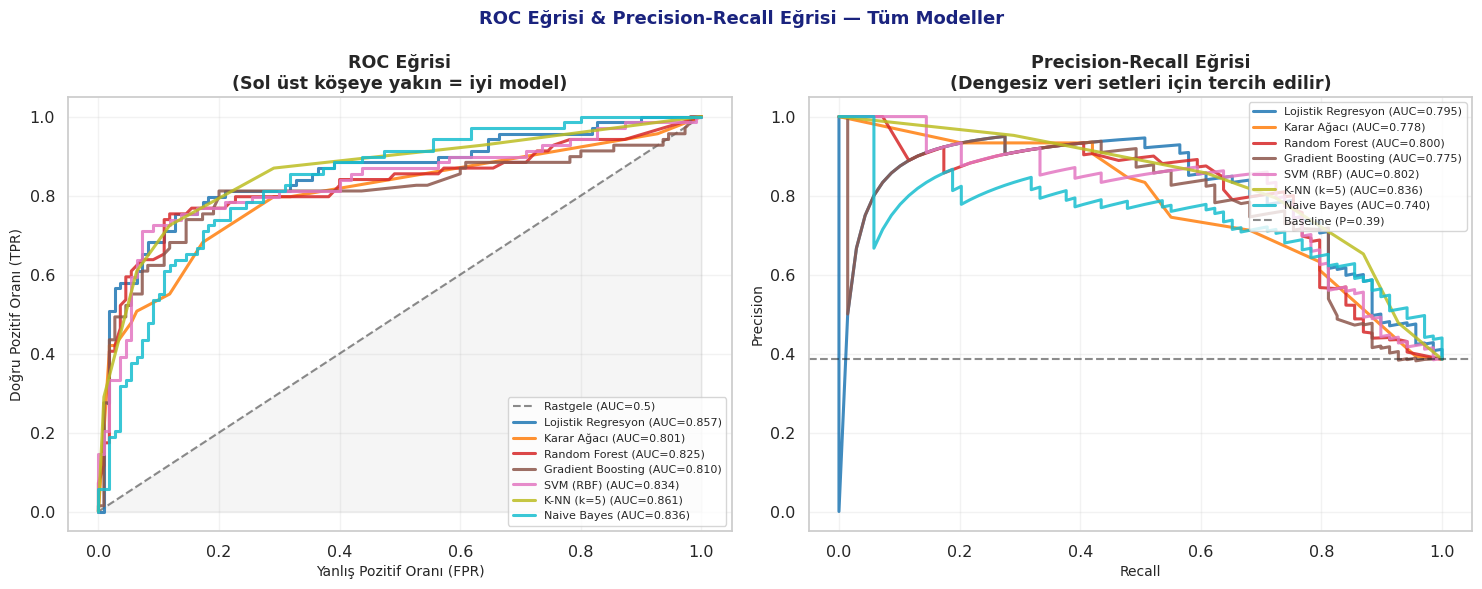

In [20]:
# ─────────────────────────────────────────────────────────────────
# DEMO 7.2: ROC Eğrisi — Tüm Modeller
# Neden? → Farklı eşik değerlerinde performans karşılaştırması
#          AUC = 1.0 mükemmel | AUC = 0.5 rastgele tahmin
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('ROC Eğrisi & Precision-Recall Eğrisi — Tüm Modeller',
             fontsize=13, fontweight='700', color=PAL['navy'])
colors_roc = plt.cm.tab10(np.linspace(0, 1, len(results)))

# ROC
ax = axes[0]
ax.plot([0,1],[0,1], 'k--', lw=1.5, alpha=0.5, label='Rastgele (AUC=0.5)')
for (name, res), clr in zip(results.items(), colors_roc):
    try:
        if hasattr(res['model'], 'predict_proba'):
            proba = res['model'].predict_proba(X_test_s)[:,1]
        else:
            proba = res['model'].decision_function(X_test_s)
        fpr, tpr, _ = roc_curve(y_test, proba)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2.2, color=clr,
                label=f'{name[:20]} (AUC={roc_auc:.3f})', alpha=0.85)
    except:
        pass
ax.set_xlabel('Yanlış Pozitif Oranı (FPR)', fontsize=10)
ax.set_ylabel('Doğru Pozitif Oranı (TPR)', fontsize=10)
ax.set_title('ROC Eğrisi\n(Sol üst köşeye yakın = iyi model)', fontweight='600')
ax.legend(fontsize=8, loc='lower right')
ax.fill_between([0,1],[0,1], alpha=0.08, color='gray')

# Precision-Recall
ax = axes[1]
for (name, res), clr in zip(results.items(), colors_roc):
    try:
        if hasattr(res['model'], 'predict_proba'):
            proba = res['model'].predict_proba(X_test_s)[:,1]
        else:
            proba = res['model'].decision_function(X_test_s)
        prec, rec, _ = precision_recall_curve(y_test, proba)
        pr_auc = auc(rec, prec)
        ax.plot(rec, prec, lw=2.2, color=clr,
                label=f'{name[:20]} (AUC={pr_auc:.3f})', alpha=0.85)
    except:
        pass
baseline = y_test.mean()
ax.axhline(baseline, color='k', lw=1.5, ls='--',
           label=f'Baseline (P={baseline:.2f})', alpha=0.5)
ax.set_xlabel('Recall', fontsize=10)
ax.set_ylabel('Precision', fontsize=10)
ax.set_title('Precision-Recall Eğrisi\n(Dengesiz veri setleri için tercih edilir)',
             fontweight='600')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

Bu görsel, makine öğrenmesi modellerinin performansını sadece tek bir karar noktasına (eşik değerine) göre değil, **tüm olası karar ihtimallerine göre** geniş bir perspektifte değerlendiren en önemli iki grafiği sunuyor.

Grafiklerden çıkarılabilecek temel bilgiler şunlardır:

* **Sol Grafik (ROC Eğrisi):** Modelin "Yanlış Alarm" (FPR) oranını artırmadan "Gerçek Pozitifleri" (TPR) ne kadar başarılı yakalayabildiğini gösterir. Çizgilerin sol üst köşeye doğru ne kadar bombeli olduğu modelin kalitesini belirler. Grafiğin sağ altındaki **AUC (Eğri Altında Kalan Alan)** değeri 1'e ne kadar yakınsa model o kadar iyidir (0.5 rastgele tahmin demektir). Bu grafikte **K-NN (0.861)** ve **Lojistik Regresyon (0.857)** sınıfları birbirinden ayırmada en başarılı modeller olarak zirveyi paylaşıyor.
* **Sağ Grafik (Precision-Recall Eğrisi):** Titanic gibi sınıfların eşit dağılmadığı (hayatını kaybedenlerin daha çok olduğu dengesiz) veri setlerinde, ROC eğrisine kıyasla daha acımasız ve net bir performans ölçütüdür. Modelin "kurtuldu" dediklerinin ne kadarı gerçekten kurtuldu (Precision) ve gerçekte kurtulanların ne kadarını bulabildik (Recall) dengesine bakar. Çizgi sağ üst köşeye ne kadar yakınsa o kadar iyidir. Burada ise **K-NN (0.836)** ve **SVM (0.802)** en ideal dengeyi kurarak öne çıkıyor.

**Özetle:** Sadece tek bir doğruluk (% Accuracy) skoruna bakmak bazen yanıltıcı olabilir. Bu eğriler, modellerimizin rastgele atış yapmaktan (grafiklerdeki kesik çizgiler) çok daha akıllıca kararlar verdiğini ve farklı eşik değerlerinde dahi performanslarını koruduklarını matematiksel olarak kanıtlıyor.

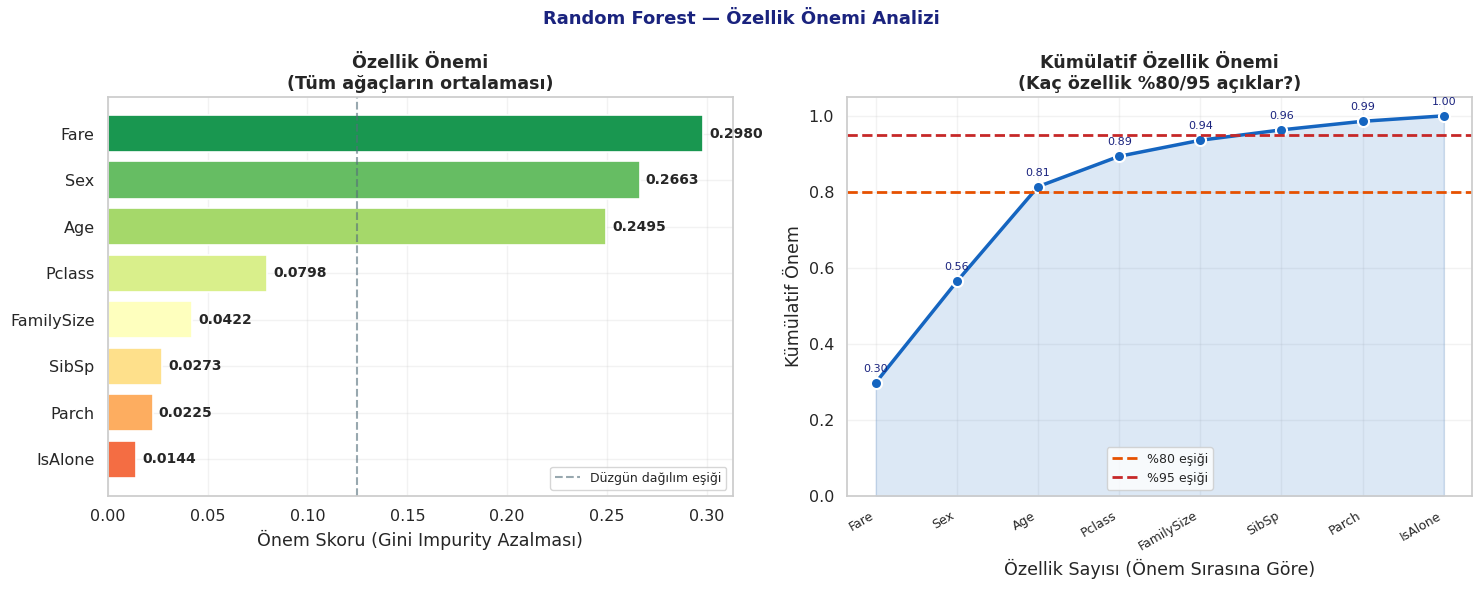

In [21]:
# ─────────────────────────────────────────────────────────────────
# DEMO 7.3: Feature Importance (Random Forest)
# Neden? → Model hangi özelliklere ne kadar önem verdi?
#          Black-box modeli biraz şeffaflaştırır
# ─────────────────────────────────────────────────────────────────
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_,
                         index=feature_cols).sort_values(ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Random Forest — Özellik Önemi Analizi',
             fontsize=13, fontweight='700', color=PAL['navy'])

# Bar chart
ax = axes[0]
colors_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importances)))
bars = ax.barh(importances.index, importances.values,
               color=colors_fi, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.003, bar.get_y()+bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='600')
ax.set_xlabel('Önem Skoru (Gini Impurity Azalması)')
ax.set_title('Özellik Önemi\n(Tüm ağaçların ortalaması)', fontweight='600')
ax.axvline(1/len(feature_cols), color=PAL['gray'], lw=1.5, ls='--',
           alpha=0.6, label='Düzgün dağılım eşiği')
ax.legend(fontsize=9)

# Kümülatif önem
ax = axes[1]
imp_sorted = importances.sort_values(ascending=False)
cum_imp = imp_sorted.cumsum()
ax.plot(range(1, len(cum_imp)+1), cum_imp.values, 'o-',
        color=PAL['blue'], lw=2.5, ms=8, mec='white', mew=1.5)
ax.fill_between(range(1, len(cum_imp)+1), cum_imp.values,
                alpha=0.15, color=PAL['blue'])
ax.axhline(0.80, color=PAL['orange'], lw=2, ls='--', label='%80 eşiği')
ax.axhline(0.95, color=PAL['red'],    lw=2, ls='--', label='%95 eşiği')
ax.set_xlabel('Özellik Sayısı (Önem Sırasına Göre)')
ax.set_ylabel('Kümülatif Önem')
ax.set_title('Kümülatif Özellik Önemi\n(Kaç özellik %80/95 açıklar?)',
             fontweight='600')
ax.set_ylim(0, 1.05); ax.legend(fontsize=9)
ax.set_xticks(range(1, len(imp_sorted)+1))
ax.set_xticklabels(imp_sorted.index, rotation=30, ha='right', fontsize=9)
for i, (feat, cum) in enumerate(zip(imp_sorted.index, cum_imp.values)):
    ax.annotate(f'{cum:.2f}', (i+1, cum), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=8, color=PAL['navy'])
plt.tight_layout()
plt.show()

Bu görsel, eğittiğimiz **Random Forest (Rastgele Orman)** modelinin tahmin yaparken hangi değişkenlere daha çok güvendiğini (ağırlık verdiğini) gösteren **Özellik Önemi (Feature Importance)** analizidir. Önceki veri analizlerinin aksine, bu tablo doğrudan *modelin kendi iç karar mekanizmasını* yansıtır.

Grafiklerden çıkarılabilecek temel bulgular şunlardır:

* **Sol Grafik (Özellik Önemi):** Modelin içindeki yüzlerce karar ağacının ortalamasına göre, hayatta kalmayı tahmin etmede açık ara en büyük paya sahip üç değişken sırasıyla **Bilet Ücreti (Fare - %29.8)**, **Cinsiyet (Sex - %26.6)** ve **Yaş (Age - %24.9)** olmuştur. Diğer tüm değişkenlerin (yolcu sınıfı, aile boyu vb.) etkisi bu üçlünün oldukça gerisinde kalmıştır.
* **Sağ Grafik (Kümülatif Önem):** Özellikleri en önemliden en az önemliye doğru topladığımızda, modelin açıklayıcılık gücünün nasıl arttığını gösterir. Buradaki en kritik ve sevindirici bulgu şudur: Elimizdeki 8 özelliğin tamamını kullanmak zorunda değiliz! **Sadece en iyi 3 özelliği (Fare, Sex, Age) kullanarak, modelin toplam bilgi kapasitesinin %81'ine (turuncu kesik çizgiyi aştığı nokta) ulaşabiliyoruz.**

**Özetle:** Bu analiz, veri bilimi projelerinde sıklıkla başvurulan "Boyut Azaltma" taktiği için harika bir rehberdir. Modelin kafasını karıştıran ve tahmine çok az katkı sağlayan en alttaki özellikleri (IsAlone, Parch, SibSp vb.) veri setinden çöpe atarak; hem daha hızlı çalışan hem de ezberlemeye (overfitting) daha kapalı, sade bir model kurabiliriz.

---
# BÖLÜM 8: Hiperparametre Optimizasyonu
## ❓ Ne yapıyoruz?
Model parametrelerinin en iyi kombinasyonunu sistematik olarak arıyoruz.
## ❓ Neden yapıyoruz?
- Model parametreleri (`max_depth`, `n_estimators`, `C`) sonucu dramatik değiştirir
- Manuel deneme-yanılma verimsiz ve önyargılı
- Grid Search: Tüm kombinasyonları sistematik dene
- Öğrenme eğrisi: Underfitting mi Overfitting mi?
## ⚠️ Data Leakage Uyarısı
> Grid search'ü **sadece eğitim seti** üzerinde yapmalısın!
> Test setini yalnızca en son değerlendirmede kullan.

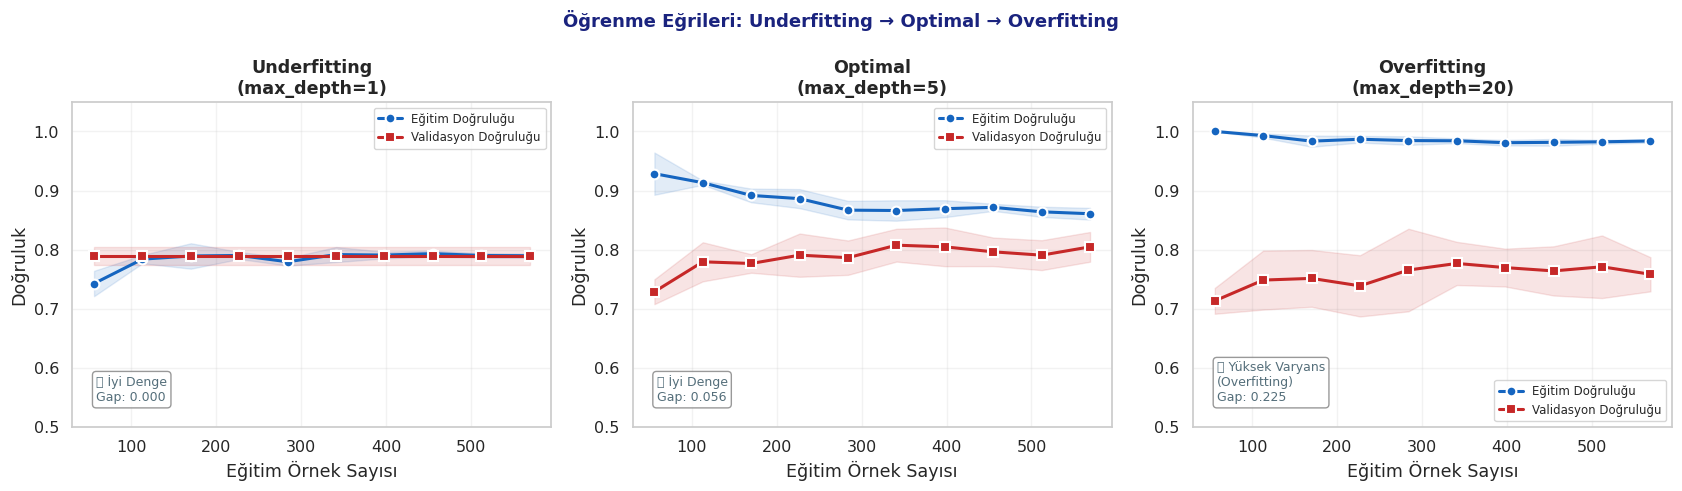

In [22]:
# ─────────────────────────────────────────────────────────────────
# DEMO 8.1: Öğrenme Eğrisi — Underfitting vs Overfitting
# Neden? → Kaç veriyle/derinlikle optimal noktaya ulaşıyoruz?
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Öğrenme Eğrileri: Underfitting → Optimal → Overfitting',
             fontsize=13, fontweight='700', color=PAL['navy'])
configs = [
    (DecisionTreeClassifier(max_depth=1,  random_state=42), 'Underfitting\n(max_depth=1)'),
    (DecisionTreeClassifier(max_depth=5,  random_state=42), 'Optimal\n(max_depth=5)'),
    (DecisionTreeClassifier(max_depth=20, random_state=42), 'Overfitting\n(max_depth=20)'),
]
for ax, (model, title) in zip(axes, configs):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train_s, y_train,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=5, scoring='accuracy', n_jobs=-1
    )
    tr_mean = train_scores.mean(axis=1)
    tr_std  = train_scores.std(axis=1)
    va_mean = val_scores.mean(axis=1)
    va_std  = val_scores.std(axis=1)
    ax.plot(train_sizes, tr_mean, 'o-', color=PAL['blue'],
            lw=2.2, ms=7, label='Eğitim Doğruluğu', mec='white', mew=1.5)
    ax.plot(train_sizes, va_mean, 's-', color=PAL['red'],
            lw=2.2, ms=7, label='Validasyon Doğruluğu', mec='white', mew=1.5)
    ax.fill_between(train_sizes, tr_mean-tr_std, tr_mean+tr_std,
                    alpha=0.12, color=PAL['blue'])
    ax.fill_between(train_sizes, va_mean-va_std, va_mean+va_std,
                    alpha=0.12, color=PAL['red'])
    gap = tr_mean[-1] - va_mean[-1]
    status = ('🔴 Yüksek Bias\n(Underfitting)' if tr_mean[-1] < 0.78
              else '🔴 Yüksek Varyans\n(Overfitting)' if gap > 0.1
              else '✅ İyi Denge')
    ax.text(0.05, 0.08, f'{status}\nGap: {gap:.3f}',
            transform=ax.transAxes, fontsize=9, color=PAL['gray'],
            bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.8))
    ax.set_xlabel('Eğitim Örnek Sayısı'); ax.set_ylabel('Doğruluk')
    ax.set_title(title, fontweight='600')
    ax.legend(fontsize=8.5); ax.set_ylim(0.5, 1.05)
plt.tight_layout()
plt.show()

Bu görsel, bir Karar Ağacı (Decision Tree) modelinin derinliği (`max_depth`) değiştirildiğinde, modelin **öğrenme** ile **ezberleme** arasındaki ince çizgide nasıl gidip geldiğini gösteren **Öğrenme Eğrileri (Learning Curves)** analizidir.

Grafiklerde **Mavi Çizgi** modelin eğitim verisindeki başarısını, **Kırmızı Çizgi** ise daha önce hiç görmediği test (validasyon) verisindeki başarısını temsil eder. Çıkarılacak temel dersler şunlardır:

* **Sol Grafik (Underfitting - Eksik Öğrenme):** Ağaç derinliği sadece 1 (`max_depth=1`) yapıldığında model o kadar basit (yetersiz) kalmıştır ki; ne eğitim verisini öğrenebilmiş ne de test verisinde başarılı olabilmiştir. İki çizgi de %80'in altında takılıp kalmıştır. Model verinin içindeki hikâyeyi kavrayamamıştır.
* **Orta Grafik (Optimal - İdeal Denge):** Derinlik 5'e (`max_depth=5`) çıkarıldığında model ideal kapasitesine ulaşmıştır. Eğitim başarısı ile test başarısı birbirine çok yakın bir şekilde paralel ilerlemektedir (aralarındaki "gap/boşluk" sadece 0.056). Model kuralları iyi genellemiş ve ezberden kaçınmıştır.
* **Sağ Grafik (Overfitting - Aşırı Öğrenme/Ezberleme):** Derinlik 20'ye (`max_depth=20`) çıkarılarak model gereğinden fazla karmaşıklaştırılmıştır. Mavi çizgi neredeyse %100'e (1.0) yapışmıştır; yani model eğitim verisindeki her bir detayı adeta noktası virgülüne **ezberlemiştir**. Ancak bu ezber, kırmızı çizginin çok aşağılarda kalmasına sebep olmuştur. Aradaki devasa boşluk (gap: 0.225), modelin yeni bir veri gördüğünde ne kadar çuvalladığının (Yüksek Varyans) net bir kanıtıdır.

**Özetle:** Bu görsel, makine öğrenmesinde amacımızın modeli olabildiğince karmaşıklaştırmak (eğitimde %100 başarı aramak) değil, eğitim ve test performansları arasındaki farkın (gap) minimum olduğu, genelleme yeteneği yüksek **optimal noktayı (orta grafik)** bulmak olduğunu kanıtlamaktadır.

✅ Grid Search tamamlandı
   En iyi parametreler : {'max_depth': 10, 'n_estimators': 50}
   En iyi CV doğruluğu: 0.8231
   Test doğruluğu     : 0.8101


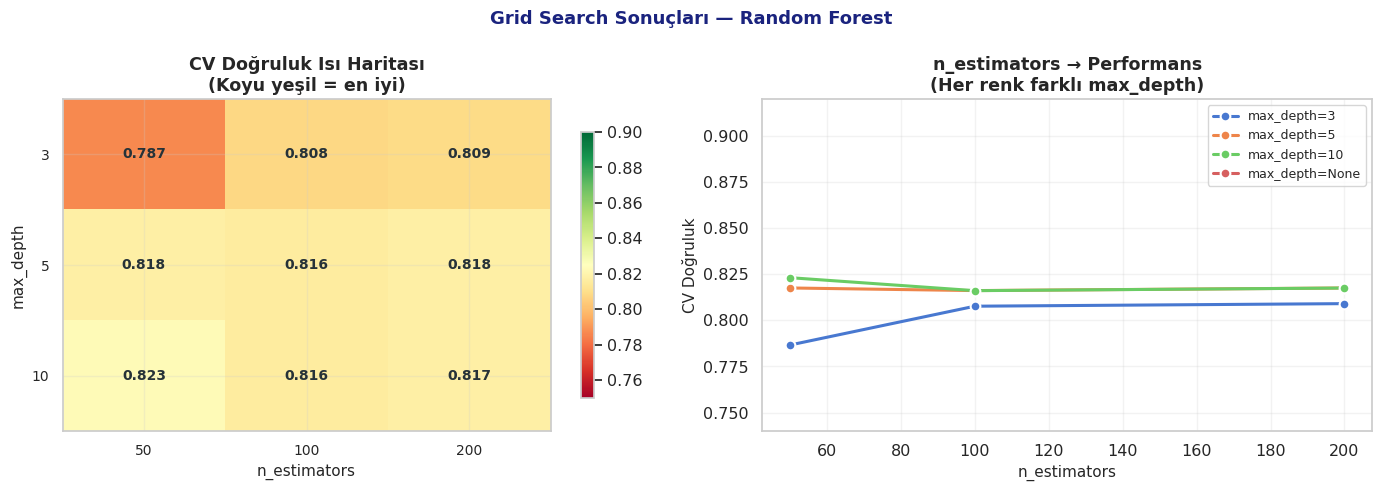

In [23]:
# ─────────────────────────────────────────────────────────────────
# DEMO 8.2: Grid Search — Hiperparametre Isı Haritası
# Neden? → Parametre uzayını görsel olarak keşfetmek
# ─────────────────────────────────────────────────────────────────
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [3, 5, 10, None],
}
gs = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1)
gs.fit(X_train_s, y_train)
print(f'✅ Grid Search tamamlandı')
print(f'   En iyi parametreler : {gs.best_params_}')
print(f'   En iyi CV doğruluğu: {gs.best_score_:.4f}')
print(f'   Test doğruluğu     : {accuracy_score(y_test, gs.predict(X_test_s)):.4f}')

# Isı haritası
results_df = pd.DataFrame(gs.cv_results_)
pivot = results_df.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_n_estimators')
pivot.index = pivot.index.map(lambda x: str(x) if x is not None else 'None')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Grid Search Sonuçları — Random Forest', fontsize=13,
             fontweight='700', color=PAL['navy'])

ax = axes[0]
im = ax.imshow(pivot.values, cmap='RdYlGn', vmin=0.75, vmax=0.90, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([str(c) for c in pivot.columns], fontsize=10)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=10)
ax.set_xlabel('n_estimators', fontsize=11)
ax.set_ylabel('max_depth', fontsize=11)
ax.set_title('CV Doğruluk Isı Haritası\n(Koyu yeşil = en iyi)', fontweight='600')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=10, fontweight='700',
                color='white' if val > 0.86 else '#263238')

# Parametre etkisi
ax = axes[1]
for depth in param_grid['max_depth']:
    mask = results_df['param_max_depth'] == depth
    sub  = results_df[mask].sort_values('param_n_estimators')
    lbl  = f'max_depth={depth}'
    ax.plot(sub['param_n_estimators'], sub['mean_test_score'],
            'o-', lw=2.2, ms=7, label=lbl, mec='white', mew=1.5)
ax.set_xlabel('n_estimators', fontsize=11)
ax.set_ylabel('CV Doğruluk', fontsize=11)
ax.set_title('n_estimators → Performans\n(Her renk farklı max_depth)',
             fontweight='600')
ax.legend(fontsize=9)
ax.set_ylim(0.74, 0.92)
plt.tight_layout()
plt.show()

Bu görsel, eğittiğimiz Random Forest (Rastgele Orman) modelinin en yüksek performansı gösterebilmesi için doğru ayarları sistematik bir şekilde aradığımız **Hiperparametre Optimizasyonu (Grid Search)** aşamasını özetlemektedir.

Modelin kendi kendine öğrenemediği, bizim dışarıdan vermemiz gereken ayarlara "hiperparametre" denir. Grafiklerden çıkarılabilecek temel sonuçlar şunlardır:

* **Sol Grafik (Isı Haritası):** İki kritik ayarın, yani `n_estimators` (ormandaki toplam ağaç sayısı) ve `max_depth` (ağaçların maksimum dal derinliği), farklı kombinasyonlarının başarı oranlarını gösterir. Renk açıldıkça (veya yeşile yaklaştıkça) modelin doğruluğu artmaktadır. En yüksek başarı oranına (**0.823**), `max_depth=10` ve `n_estimators=50` ikilisiyle ulaşıldığını net bir şekilde görebiliyoruz.
* **Sağ Grafik (Çizgi Grafik):** Ağaç sayısını artırmanın her zaman işe yarayıp yaramadığını detaylandırır.
    * Mavi çizgiye (`max_depth=3`) bakıldığında, ağaç sayısı 50'den 100'e çıkarken performansın arttığı, sonrasında ise yatay seyrettiği (düzleştiği) görülür.
    * Yeşil (`max_depth=10`) ve Turuncu (`max_depth=5`) çizgilerde ise ağaç sayısını 50'den 200'e çıkarmanın başarıyı artırmadığı, aksine çok hafif bir düşüşe bile sebep olduğu fark ediliyor.

**Özetle:** Bu analiz, model ayarlarını körü körüne denemek yerine bilimsel bir yaklaşımla bulmamızı sağlar. Bize "Daha fazla ağaç her zaman daha iyi değildir" dersini verir; böylece hem en doğru modeli buluruz hem de gereksiz yere devasa modeller kurmaktan kaçınarak işlemci (CPU) gücünden tasarruf ederiz.

---
# BÖLÜM 9: Tam Sklearn Pipeline
## ❓ Ne yapıyoruz?
Tüm adımları (imputation, encoding, scaling, model) tek bir nesneye bağlıyoruz.
## ❓ Neden yapıyoruz?
- **Data leakage önler:** Scaler sadece eğitim verisine fit eder
- **Tekrar üretilebilirlik:** Train ve test aynı adımlardan geçer
- **Dağıtım kolaylığı:** Tek `pipeline.predict(X_raw)` yeterli
- **Grid Search entegrasyonu:** Tüm hiperparametreler birlikte optimize edilir
```
Ham Veri   ↓
[Imputer] → Eksik değerleri doldur
   ↓
[Scaler]  → Normalize et
   ↓
[Model]   → Tahmin yap
   ↓
Çıktı
```

In [24]:
# ─────────────────────────────────────────────────────────────────
# DEMO 9.1: Tam Pipeline Kurulumu & Görselleştirmesi
# ─────────────────────────────────────────────────────────────────
# Ham veri (preprocessing öncesi)
X_raw = df_feat[feature_cols].copy()
# Bazı değerleri tekrar NaN yapıyoruz (pipeline test için)
X_raw_with_na = X_raw.copy()
X_raw_with_na.loc[X_raw_with_na.sample(frac=0.15).index, 'Age'] = np.nan

X_tr_raw, X_te_raw, y_tr_raw, y_te_raw = train_test_split(
    X_raw_with_na, y, test_size=0.2, random_state=42, stratify=y)

# ── Pipeline tanımı ──────────────────────────────────────────────
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),     # Adım 1: Eksik doldur
    ('scaler',  StandardScaler()),                     # Adım 2: Ölçekle
    ('model',   RandomForestClassifier(               # Adım 3: Model
                    n_estimators=100,
                    max_depth=5,
                    random_state=42)),
])

# ── Eğit ve değerlendir ──────────────────────────────────────────
pipeline.fit(X_tr_raw, y_tr_raw)
pip_pred = pipeline.predict(X_te_raw)
pip_acc  = accuracy_score(y_te_raw, pip_pred)

print('🔄 Pipeline Adımları:')
for i, (name, step) in enumerate(pipeline.steps):
    print(f'   {i+1}. {name:<10} → {type(step).__name__}')
print(f'\n✅ Pipeline Test Doğruluğu: {pip_acc:.4f}')

# ── Grid Search içinde Pipeline ──────────────────────────────────
pipe_params = {
    'model__n_estimators': [50, 100],
    'model__max_depth':    [3, 5, 10],
    'imputer__strategy':   ['mean', 'median'],
}
pipe_gs = GridSearchCV(pipeline, pipe_params, cv=5,
                        scoring='accuracy', n_jobs=-1)
pipe_gs.fit(X_tr_raw, y_tr_raw)

print(f'\n🔍 Pipeline + GridSearch En İyi Parametreler:')
for k, v in pipe_gs.best_params_.items():
    print(f'   {k:<35} = {v}')
print(f'\n🏆 En İyi CV: {pipe_gs.best_score_:.4f}')
print(f'🏆 Test Doğruluk: {accuracy_score(y_te_raw, pipe_gs.predict(X_te_raw)):.4f}')

🔄 Pipeline Adımları:
   1. imputer    → SimpleImputer
   2. scaler     → StandardScaler
   3. model      → RandomForestClassifier

✅ Pipeline Test Doğruluğu: 0.7933

🔍 Pipeline + GridSearch En İyi Parametreler:
   imputer__strategy                   = median
   model__max_depth                    = 5
   model__n_estimators                 = 100

🏆 En İyi CV: 0.8147
🏆 Test Doğruluk: 0.7933


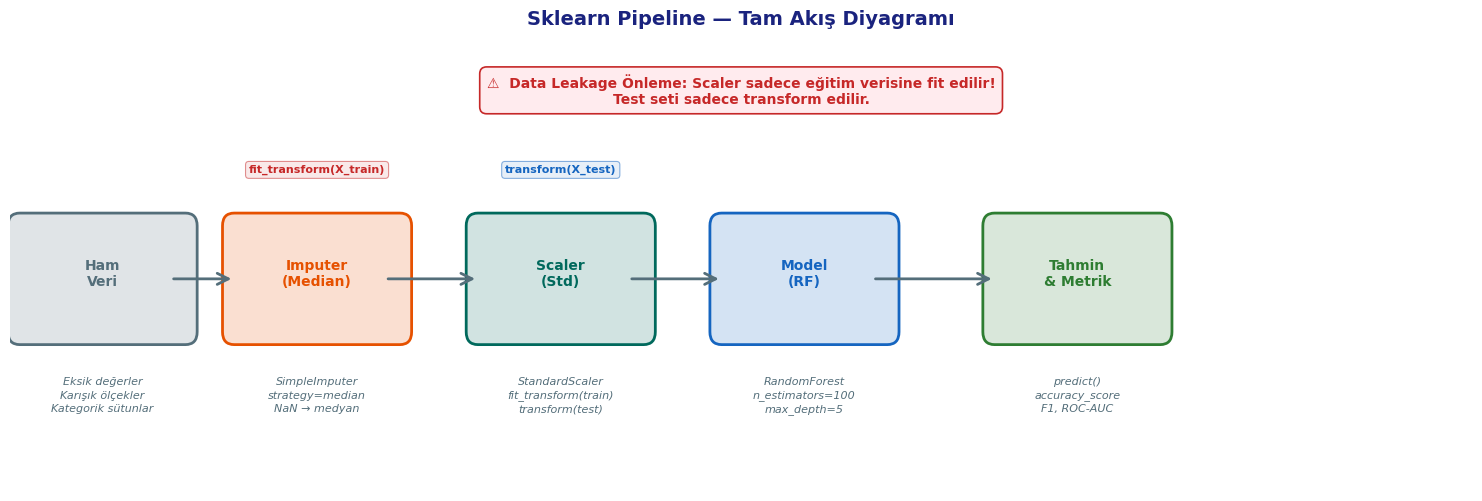

In [27]:
# ─────────────────────────────────────────────────────────────────
# DEMO 9.2: Pipeline Akış Diyagramı
# ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlim(0, 15); ax.set_ylim(0, 4)
ax.set_axis_off()
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
fig.suptitle('Sklearn Pipeline — Tam Akış Diyagramı', fontsize=14,
             fontweight='700', color=PAL['navy'], y=1.0)

steps_pipe = [
    ('Ham\nVeri', 0.8, PAL['gray'],   'Eksik değerler\nKarışık ölçekler\nKategorik sütunlar'),
    ('Imputer\n(Median)', 3.0, PAL['orange'], 'SimpleImputer\nstrategy=median\nNaN → medyan'),
    ('Scaler\n(Std)', 5.5, PAL['teal'],   'StandardScaler\nfit_transform(train)\ntransform(test)'),
    ('Model\n(RF)', 8.0, PAL['blue'],   'RandomForest\nn_estimators=100\nmax_depth=5'),
    ('Tahmin\n& Metrik', 10.8, PAL['green'],  'predict()\naccuracy_score\nF1, ROC-AUC'),
]

for i, (lbl, x, clr, detail) in enumerate(steps_pipe):
    # Ana kutu
    # box = plt.FancyBboxPatch((x-0.7, 1.5), 1.7, 1.0,

    box = mpatches.FancyBboxPatch((x-0.7, 1.5), 1.7, 1.0,
        boxstyle='round,pad=0.12', facecolor=to_rgba(clr, 0.18),
        edgecolor=clr, linewidth=2.0)
    ax.add_patch(box)
    ax.text(x+0.15, 2.05, lbl, ha='center', va='center',
            fontsize=10, fontweight='700', color=clr)
    # Detay kutusu
    ax.text(x+0.15, 0.9, detail, ha='center', va='center',
            fontsize=8, color=PAL['gray'], linespacing=1.4,
            style='italic')
    # Ok
    if i < len(steps_pipe)-1:
        ax.annotate('', xy=(steps_pipe[i+1][1]-0.7, 2.0),
                    xytext=(x+0.85, 2.0),
                    arrowprops=dict(arrowstyle='->', color=PAL['gray'],
                                   lw=2.0, mutation_scale=20))

# Fit/Transform etiketi
for x_pos, lbl, clr in [(3.0, 'fit_transform(X_train)', PAL['red']),
                          (5.5, 'transform(X_test)', PAL['blue'])]:
    ax.text(x_pos+0.15, 3.0, lbl, ha='center', fontsize=8,
            color=clr, fontweight='600',
            bbox=dict(boxstyle='round', fc=to_rgba(clr,0.1),
                      ec=to_rgba(clr,0.5), lw=0.8))

ax.text(7.5, 3.65, '⚠️  Data Leakage Önleme: Scaler sadece eğitim'
        ' verisine fit edilir!\nTest seti sadece transform edilir.',
        ha='center', fontsize=10, color=PAL['red'], fontweight='600',
        bbox=dict(boxstyle='round,pad=0.5', fc='#FFEBEE', ec=PAL['red'], lw=1.2))
plt.tight_layout()
plt.show()

---
# BÖLÜM 10: QML'ye Köprü — Klasik Pipeline'dan Kuantuma
## Öğrendiklerimizi Karşılaştıralım
| Adım | Klasik ML | Quantum ML |
|------|-----------|------------|
| **Veri Temsili** | `x ∈ Rⁿ` vektör | `\|ψ(x)⟩ ∈ H²ⁿ` kuantum durumu |
| **Model** | DNN, SVM, RF | VQC, QNN, QSVM |
| **Parametre** | Ağırlık matrisleri W | Rotasyon açıları θ |
| **Eğitim** | Backpropagation | Parameter-Shift Rule |
| **Optimizer** | SGD, Adam | Adam, QNG |
| **Değerlendirme** | Accuracy, F1, AUC | Aynı metrikler! |
| **Donanım** | CPU / GPU | Kuantum bilgisayar |
## 🚀 Sonraki Adım
Bu notebook'ta gördüğün her şey QML'de de var — sadece "kuantum versiyonu" ile:
```python
# Klasik
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Kuantum (PennyLane)
@qml.qnode(dev)
def quantum_model(params, x):
    qml.AngleEmbedding(x, wires=range(n_qubits))
    qml.StronglyEntanglingLayers(params, wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))
```

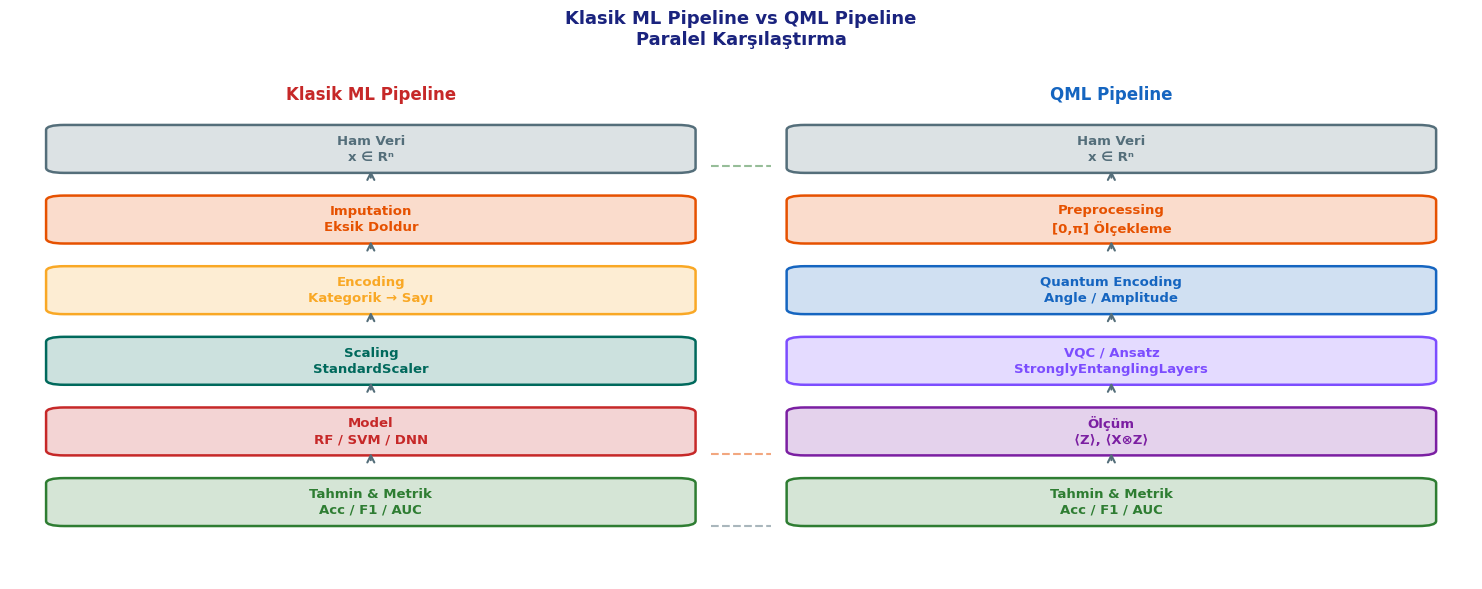

In [28]:
# ─────────────────────────────────────────────────────────────────
# DEMO 10.1: Klasik ML vs QML Karşılaştırma Görselleştirmesi
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Klasik ML Pipeline vs QML Pipeline\nParalel Karşılaştırma',
             fontsize=13, fontweight='700', color=PAL['navy'])

# Sol: Klasik
ax = axes[0]
ax.set_xlim(0, 4); ax.set_ylim(0, 10); ax.set_axis_off()
ax.text(2, 9.5, 'Klasik ML Pipeline', ha='center', fontsize=12,
        fontweight='700', color=PAL['red'])
cl_steps = [
    ('Ham Veri\nx ∈ Rⁿ',                  PAL['gray']),
    ('Imputation\nEksik Doldur',            PAL['orange']),
    ('Encoding\nKategorik → Sayı',          PAL['gold']),
    ('Scaling\nStandardScaler',             PAL['teal']),
    ('Model\nRF / SVM / DNN',              PAL['red']),
    ('Tahmin & Metrik\nAcc / F1 / AUC',    PAL['green']),
]
for i, (lbl, clr) in enumerate(cl_steps):
    y = 8.5 - i * 1.4
    box = mpatches.FancyBboxPatch((0.3, y-0.35), 3.4, 0.75,
        boxstyle='round,pad=0.1', facecolor=to_rgba(clr, 0.2),
        edgecolor=clr, linewidth=1.8)
    ax.add_patch(box)
    ax.text(2, y+0.02, lbl, ha='center', va='center',
            fontsize=9.5, fontweight='600', color=clr, linespacing=1.3)
    if i < len(cl_steps)-1:
        ax.annotate('', xy=(2, y-0.35), xytext=(2, y-0.6),
                    arrowprops=dict(arrowstyle='->', color=PAL['gray'], lw=1.5))

# Sağ: QML
ax = axes[1]
ax.set_xlim(0, 4); ax.set_ylim(0, 10); ax.set_axis_off()
ax.text(2, 9.5, 'QML Pipeline', ha='center', fontsize=12,
        fontweight='700', color=PAL['blue'])
qml_steps = [
    ('Ham Veri\nx ∈ Rⁿ',                     PAL['gray']),
    ('Preprocessing\n[0,π] Ölçekleme',         PAL['orange']),
    ('Quantum Encoding\nAngle / Amplitude',     PAL['blue']),
    ('VQC / Ansatz\nStronglyEntanglingLayers', PAL['purple']),
    ('Ölçüm\n⟨Z⟩, ⟨X⊗Z⟩',                   PAL['violet'] if 'violet' in PAL else '#7B1FA2'),
    ('Tahmin & Metrik\nAcc / F1 / AUC',        PAL['green']),
]
for i, (lbl, clr) in enumerate(qml_steps):
    y = 8.5 - i * 1.4
    box = mpatches.FancyBboxPatch((0.3, y-0.35), 3.4, 0.75,
        boxstyle='round,pad=0.1', facecolor=to_rgba(clr, 0.2),
        edgecolor=clr, linewidth=1.8)
    ax.add_patch(box)
    ax.text(2, y+0.02, lbl, ha='center', va='center',
            fontsize=9.5, fontweight='600', color=clr, linespacing=1.3)
    if i < len(qml_steps)-1:
        ax.annotate('', xy=(2, y-0.35), xytext=(2, y-0.6),
                    arrowprops=dict(arrowstyle='->', color=PAL['gray'], lw=1.5))

# Eşdeğer adımlar arası köprü çizgileri
for i, (clr) in enumerate([PAL['gray'], PAL['orange'], None, None, None, PAL['green']]):
    if clr:
        y = 8.5 - i * 1.4 + 0.02
        # Sol eksenin sağı - sağ eksenin solu arası çizgi (figür koordinatlarında)
        fig.add_artist(plt.Line2D([0.48, 0.52], [0.12+i*0.12, 0.12+i*0.12],
                                   transform=fig.transFigure,
                                   color=clr, lw=1.5, ls='--', alpha=0.5))
plt.tight_layout()
plt.show()

In [29]:
# ─────────────────────────────────────────────────────────────────
# ÖZET RAPOR
# ─────────────────────────────────────────────────────────────────
print('═'*65)
print('  📊  KLASİK ML WORKSHOP — ÖZET RAPOR')
print('═'*65)
print('\n🗂  VERİ:')
print(f'   Titanic Veri Seti   : {len(df):>4} yolcu')
print(f'   Kullanılan Özellik  : {len(feature_cols)}')
print(f'   Türetilen Özellik   : 5 (FamilySize, IsAlone, AgeGroup, FareBand, Title)')

print('\n🤖  MODEL PERFORMANSLARI (Test Seti):')
print(f'   {"":<28} {"Acc":>6} {"CV±Std":>12}')
print('   ' + '─'*50)
for name, res in sorted(results.items(), key=lambda x: -x[1]['test_acc']):
    mark = '🏆' if name == max(results, key=lambda n: results[n]['test_acc']) else '  '
    print(f'   {mark} {name:<26} {res["test_acc"]:>6.3f}   '
          f'{res["cv_mean"]:.3f}±{res["cv_std"]:.3f}')

best_model = max(results, key=lambda n: results[n]['test_acc'])
print(f'\n🏆  En İyi Model: {best_model}')

print('\n📋  ÖĞRENILEN ADIMLAR:')
steps_learned = [
    '1. Veri yükleme & ilk bakış (shape, dtypes, eksik)',
    '2. EDA: dağılım, korelasyon, violin/box/bar plot',
    '3. Imputation: mean/median/mode karşılaştırması',
    '4. Encoding: Label, One-Hot, Frekans',
    '5. Scaling: StandardScaler vs MinMaxScaler',
    '6. Feature Engineering: yeni anlamlı değişkenler',
    '7. Feature Importance: MI ve RF tabanlı',
    '8. Model Seçimi: 7 model 5-fold CV karşılaştırması',
    '9. Değerlendirme: CM, ROC, PR eğrisi, F1',
    '10. Hyperparameter: Grid Search + Isı Haritası',
    '11. Pipeline: Leakage önleyici tam akış',
]
for step in steps_learned:
    print(f'   ✅ {step}')

print('\n🚀  SIRADAKI ADIM: QML Workshop Notebook')
print('   Aynı pipeline, kuantum versiyonu ile!')
print('═'*65)

═════════════════════════════════════════════════════════════════
  📊  KLASİK ML WORKSHOP — ÖZET RAPOR
═════════════════════════════════════════════════════════════════

🗂  VERİ:
   Titanic Veri Seti   :  891 yolcu
   Kullanılan Özellik  : 8
   Türetilen Özellik   : 5 (FamilySize, IsAlone, AgeGroup, FareBand, Title)

🤖  MODEL PERFORMANSLARI (Test Seti):
                                   Acc       CV±Std
   ──────────────────────────────────────────────────
   🏆 SVM (RBF)                   0.827   0.827±0.016
      Random Forest               0.821   0.809±0.021
      K-NN (k=5)                  0.821   0.815±0.029
      Lojistik Regresyon          0.816   0.795±0.024
      Gradient Boosting           0.799   0.826±0.035
      Naive Bayes                 0.777   0.792±0.030
      Karar Ağacı                 0.754   0.816±0.020

🏆  En İyi Model: SVM (RBF)

📋  ÖĞRENILEN ADIMLAR:
   ✅ 1. Veri yükleme & ilk bakış (shape, dtypes, eksik)
   ✅ 2. EDA: dağılım, korelasyon, violin/box/bar plot
